### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,roc_curve, auc, roc_auc_score, precision_recall_curve, RocCurveDisplay, accuracy_score, f1_score, precision_score, recall_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

In [2]:
# %pip install xgboost

### Reading dataset

In [3]:
df = pd.read_csv("ipl-dataset_2008-2024.csv")

In [4]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')

In [6]:
df.shape

(1095, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   int64  
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [8]:
no_winner_matches = df[df["winner"].isnull()] 
no_winner_matches # 5 matches with no winner and play_of_match, 3 out which dont have target runs and target overs.

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


In [9]:
df["city"].unique()

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', nan, 'Rajkot', 'Kanpur', 'Bengaluru', 'Dubai',
       'Sharjah', 'Navi Mumbai', 'Lucknow', 'Guwahati', 'Mohali'],
      dtype=object)

In [10]:
missing_city_matches = df[df["city"].isnull()]
missing_city_matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
399,729281,2014,NaN,2014-04-17,League,YS Chahal,Sharjah Cricket Stadium,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,146.0,20.0,N,NaN,Aleem Dar,S Ravi
402,729287,2014,NaN,2014-04-19,League,PA Patel,Dubai International Cricket Stadium,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,116.0,20.0,N,NaN,Aleem Dar,AK Chaudhary
403,729289,2014,NaN,2014-04-19,League,JP Duminy,Dubai International Cricket Stadium,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,Delhi Daredevils,wickets,4.0,167.0,20.0,N,NaN,Aleem Dar,VA Kulkarni
404,729291,2014,NaN,2014-04-20,League,GJ Maxwell,Sharjah Cricket Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,7.0,192.0,20.0,N,NaN,BF Bowden,M Erasmus
406,729295,2014,NaN,2014-04-22,League,GJ Maxwell,Sharjah Cricket Stadium,Kings XI Punjab,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kings XI Punjab,runs,72.0,194.0,20.0,N,NaN,M Erasmus,S Ravi


In [11]:
missing_city_matches.shape

(51, 20)

In [12]:
df["result"].unique() # 4 unique values possible for result.

array(['runs', 'wickets', 'tie', 'no result'], dtype=object)

In [13]:
df["result_margin"].unique()

array([140.,  33.,   9.,   5.,   6.,   3.,  66.,   7.,  10.,   4.,  13.,
        45.,   8.,  29.,  18.,  23.,  12.,  65.,  25.,   1.,  14.,  41.,
       105.,  19.,  75.,  92.,  11.,  24.,  nan,  27.,  38.,  78.,  16.,
        53.,   2.,  31.,  55.,  98.,  34.,  36.,  17.,  39.,  40.,  67.,
        63.,  37.,  57.,  35.,  22.,  21.,  48.,  26.,  20.,  85.,  32.,
        76., 111.,  82.,  43.,  58.,  28.,  74.,  42.,  59.,  46.,  47.,
        86.,  44.,  87., 130.,  15.,  60.,  77.,  30.,  50.,  93.,  72.,
        62.,  97., 138.,  71., 144.,  80.,  51.,  61., 146.,  64., 102.,
       118.,  49.,  69.,  88.,  54.,  91.,  52.,  81.,  56., 112., 106.])

In [14]:
no_result_margin_macthes = df[df["result_margin"].isnull()]
no_result_margin_macthes

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
66,392190,2009,Cape Town,2009-04-23,League,YK Pathan,Newlands,Kolkata Knight Riders,Rajasthan Royals,Kolkata Knight Riders,field,Rajasthan Royals,tie,NaN,151.0,20.0,Y,NaN,MR Benson,M Erasmus
130,419121,2010,Chennai,2010-03-21,League,J Theron,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,field,Kings XI Punjab,tie,NaN,137.0,20.0,Y,NaN,K Hariharan,DJ Harper
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
328,598004,2013,Hyderabad,2013-04-07,League,GH Vihari,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,bat,Sunrisers Hyderabad,tie,NaN,131.0,20.0,Y,NaN,AK Chaudhary,S Ravi
342,598017,2013,Bangalore,2013-04-16,League,V Kohli,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,Royal Challengers Bangalore,tie,NaN,153.0,20.0,Y,NaN,M Erasmus,VA Kulkarni
416,729315,2014,Abu Dhabi,2014-04-29,League,JP Faulkner,Sheikh Zayed Stadium,Kolkata Knight Riders,Rajasthan Royals,Rajasthan Royals,bat,Rajasthan Royals,tie,NaN,153.0,20.0,Y,NaN,Aleem Dar,AK Chaudhary
475,829741,2015,Ahmedabad,2015-04-21,League,SE Marsh,"Sardar Patel Stadium, Motera",Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,tie,NaN,192.0,20.0,Y,NaN,M Erasmus,S Ravi
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
610,1082625,2017,Rajkot,2017-04-29,League,KH Pandya,Saurashtra Cricket Association Stadium,Gujarat Lions,Mumbai Indians,Gujarat Lions,bat,Mumbai Indians,tie,NaN,154.0,20.0,Y,NaN,AK Chaudhary,CB Gaffaney


In [15]:
no_result_margin_macthes.shape ### 19 matches with no result margin

(19, 20)

In [16]:
tie_matches = df[df["result"]== "tie"]
no_result_matches = df[df["result"]== "no result"]

In [17]:
print(tie_matches.shape) # 14 tie matches
print(no_result_matches.shape) # 5 no result matches

(14, 20)
(5, 20)


In [18]:
df["super_over"].unique() # 2 unique values possible

array(['N', 'Y'], dtype=object)

In [19]:
matches_settled_in_super_over = df[df["super_over"]== "Y"]
matches_settled_in_super_over.shape

(14, 20)

In [20]:
matches_settled_in_super_over[matches_settled_in_super_over["result"]== "tie"].shape

(14, 20)

In [21]:
df["method"].unique() # 2 unique values possible

array([nan, 'D/L'], dtype=object)

In [22]:
DL_method_matches = df[df["method"] == 'D/L']
DL_method_matches.shape # 21 matches

(21, 20)

In [23]:
DL_method_matches ## Target overs for all these matches are less than 20

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
38,336022,2008,Delhi,2008-05-17,League,DPMD Jayawardene,Feroz Shah Kotla,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,bat,Kings XI Punjab,runs,6.0,89.0,8.0,N,D/L,AV Jayaprakash,RE Koertzen
41,336025,2008,Kolkata,2008-05-18,League,M Ntini,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Kolkata Knight Riders,bat,Chennai Super Kings,runs,3.0,53.0,8.0,N,D/L,Asad Rauf,K Hariharan
60,392183,2009,Cape Town,2009-04-19,League,DL Vettori,Newlands,Delhi Daredevils,Kings XI Punjab,Delhi Daredevils,field,Delhi Daredevils,wickets,10.0,54.0,6.0,N,D/L,MR Benson,SD Ranade
63,392186,2009,Durban,2009-04-21,League,CH Gayle,Kingsmead,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,field,Kolkata Knight Riders,runs,11.0,69.0,9.2,N,D/L,DJ Harper,SD Ranade
89,392214,2009,Centurion,2009-05-07,League,ML Hayden,SuperSport Park,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,Chennai Super Kings,runs,12.0,187.0,18.0,N,D/L,DJ Harper,TH Wijewardene
192,501215,2011,Kochi,2011-04-18,League,BB McCullum,Nehru Stadium,Kochi Tuskers Kerala,Chennai Super Kings,Kochi Tuskers Kerala,field,Kochi Tuskers Kerala,wickets,7.0,135.0,17.0,N,D/L,K Hariharan,AL Hill
221,501245,2011,Kolkata,2011-05-07,League,Iqbal Abdulla,Eden Gardens,Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,bat,Kolkata Knight Riders,runs,10.0,52.0,10.0,N,D/L,Asad Rauf,PR Reiffel
231,501255,2011,Bangalore,2011-05-14,League,CH Gayle,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,4.0,102.0,13.0,N,D/L,RE Koertzen,RB Tiffin
429,733993,2014,Delhi,2014-05-10,League,DW Steyn,Feroz Shah Kotla,Delhi Daredevils,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,8.0,43.0,5.0,N,D/L,RM Deshpande,BNJ Oxenford
476,829743,2015,Visakhapatnam,2015-04-22,League,DA Warner,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,Sunrisers Hyderabad,runs,16.0,118.0,12.0,N,D/L,RK Illingworth,VA Kulkarni


In [24]:
less_target_overs_matches = df[df["target_overs"]<20]
less_target_overs_matches.shape

(30, 20)

In [25]:
less_target_overs_matches[less_target_overs_matches["method"]== "D/L"].shape

(21, 20)

In [26]:
less_target_overs_matches[less_target_overs_matches["method"]!= "D/L"]

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
28,336010,2008,Kolkata,2008-05-08,League,SC Ganguly,Eden Gardens,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders,bat,Kolkata Knight Riders,runs,5.0,130.0,16.0,N,NaN,Asad Rauf,IL Howell
53,336012,2008,Bangalore,2008-05-28,League,CRD Fernando,M Chinnaswamy Stadium,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,9.0,123.0,18.0,N,NaN,BF Bowden,AV Jayaprakash
249,548307,2012,Kolkata,2012-04-05,League,IK Pathan,Eden Gardens,Kolkata Knight Riders,Delhi Daredevils,Delhi Daredevils,field,Delhi Daredevils,wickets,8.0,98.0,12.0,N,NaN,S Asnani,HDPK Dharmasena
391,598068,2013,Bangalore,2013-05-18,League,V Kohli,M Chinnaswamy Stadium,Royal Challengers Bangalore,Chennai Super Kings,Chennai Super Kings,field,Royal Challengers Bangalore,runs,24.0,107.0,8.0,N,NaN,C Shamshuddin,RJ Tucker
418,733971,2014,Ranchi,2014-05-02,League,RA Jadeja,JSCA International Stadium Complex,Chennai Super Kings,Kolkata Knight Riders,Chennai Super Kings,bat,Chennai Super Kings,runs,34.0,149.0,17.0,N,NaN,AK Chaudhary,NJ Llong
489,829771,2015,Bangalore,2015-05-02,League,Mandeep Singh,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,112.0,10.0,N,NaN,JD Cloete,PG Pathak
506,829803,2015,Chandigarh,2015-05-13,League,AR Patel,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Kings XI Punjab,runs,22.0,107.0,10.0,N,NaN,JD Cloete,C Shamshuddin
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
1083,1426298,2024,Kolkata,2024-05-11,League,CV Varun,"Eden Gardens, Kolkata",Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,Kolkata Knight Riders,runs,18.0,158.0,16.0,N,NaN,UV Gandhe,Vinod Seshan


#### Prima facie insights from data
1. There is data of 1095 matches, each match described using 20 columns / features.
2. There are 5 matches in which "winner" is not mentioned. Theses are also the only matches where no "player_of_match" is mentioned. These matches were abandoned in the middle, probably due to rain, security reasons, etc.
3. There are 3 matches where "target_runs" and "target_overs" are missing, all of which belong form a subset of the 5 abandoned matches. So a target was given by a team in the remaining 2 matches. Hence we can say that out of the 5 matches, 2 matches where there where teams played the first innings, but match got abandoned before or during the second innings. 3 matches were abandoned before or during the first innings.
4. There are 51 matches where the city is missing. This would be considered a fault while creating dataset. All the other columns for the matches have been corrrectly mentioned. We cannot simply ignore these many matches, they constitue roughly 4.6% (51/1095) matches.
5. There are 19 matches with no result margin. That is because these matches where either abandoned(5 matches) or the winner was decided in super over(14 matches)
6. All 14 matches that were "tie", were settled in super over.
7. 21 matches were settled by Duckworth-Lewis(D/L) method. All of these matches had target overs less than 20, and were proabably affected by rain. Second innings was not completed in these matches and D/L method was used
8. There are 9 other matches also where target overs were less than 20. These were also rain affected matches that resulted in reduction of overs in second innnings, but the game was coompleted.


#### Basic definition of each feature
1. id: A unique identifier assigned to each match.
2. season: The year in which the IPL season took place.
3. city: The city where the match was played.
4. date: The date on which the match was held.
5. match_type: Type of the match (e.g., League, Playoff, Final).
6. player_of_match: The player who was awarded “Player of the Match” for their performance.
7. venue: The stadium or ground where the match was played.
8. team1: The first team listed in the fixture.
9. team2: The second team listed in the fixture.
10. toss_winner: The team that won the toss before the match began.
11. toss_decision: The decision made by the toss-winning team—either to bat or to field first.
12. winner: The team that won the match.
13. result: The method of victory—either by runs, wickets, or other (e.g., tie, no result).
14. result_margin: The margin by which the match was won (e.g., number of runs or wickets).
15. target_runs: The number of runs set as a target for the chasing team.
16. target_overs: The number of overs available to chase the target.
17. super_over: Indicates whether the match was decided by a super over (‘Y’ for Yes, ‘N’ for No).
18. method: The method used to decide the match result if it was interrupted (e.g., Duckworth–Lewis method).
19. umpire1: Name of the first on-field umpire officiating the match.
20. umpire2: Name of the second on-field umpire officiating the match.

### Detailed univariate analysis for features and data preprocessing

#### 1. Team Names

In [27]:
unique_team_names = set(df["team1"]) | set(df["team2"])
unique_team_names

{'Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad'}

From domain knowledge, we know that "Rising Pune Supergiants" old name for "Rising Pune Supergiant". Similarly, "Royal Challengers Bangalore" is the old name for "Royal Challengers Bengaluru", "Kings XI Punjab" is the old name for "Punjab Kings" and "Delhi Daredevils" is the old name for "Delhi Capitals".

We'll replace the old names with new names, so that we dont get incomplete insights for the teams.

In [28]:
df.replace("Rising Pune Supergiants", "Rising Pune Supergiant", inplace=True)
df.replace("Royal Challengers Bangalore", "Royal Challengers Bengaluru", inplace=True)
df.replace("Kings XI Punjab", "Punjab Kings", inplace=True)
df.replace("Delhi Daredevils", "Delhi Capitals", inplace=True)

In [29]:
unique_team_names = set(df["team1"]) | set(df["team2"])
unique_team_names

{'Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad'}

In [30]:
team_stats = []

for team in unique_team_names:
    matches = df[(df["team1"] == team) | (df["team2"] == team)]
    played = matches.shape[0]

    tosses_won = (matches["toss_winner"] == team).sum()
    matches_won = (matches["winner"] == team).sum()
    matches_with_no_result = (matches["result"]== "no result").sum()
    matches_lost = (played - matches_won - matches_with_no_result)
    
    match_win_percentage = (matches_won / played) * 100
    toss_win_percentage = (tosses_won / played) * 100

    finals_played = (matches["match_type"] == "Final").sum()
    title_wins = ((matches["match_type"] == "Final") & (matches["winner"] == team)).sum()

    team_stats.append({
        "team": team,
        "matches_played": played,
        "matches_won": matches_won,
        "matches_lost": matches_lost,
        "matches_with_no_result": matches_with_no_result,
        "match_win_percentage": round(match_win_percentage, 2),
        "toss_win_percentage": round(toss_win_percentage, 2),
        "finals_played": round(finals_played, 2),
        "title_wins": round(title_wins, 2),
    })

team_df = pd.DataFrame(team_stats)

team_df

,team,matches_played,matches_won,matches_lost,matches_with_no_result,match_win_percentage,toss_win_percentage,finals_played,title_wins
0,Lucknow Super Giants,44,24,19,1,54.55,43.18,0,0
1,Delhi Capitals,252,115,135,2,45.63,51.59,1,0
2,Mumbai Indians,261,144,117,0,55.17,54.79,6,5
3,Gujarat Lions,30,13,17,0,43.33,50.00,0,0
4,Deccan Chargers,75,29,46,0,38.67,57.33,1,1
5,Kochi Tuskers Kerala,14,6,8,0,42.86,57.14,0,0
6,Chennai Super Kings,238,138,99,1,57.98,51.26,10,5
7,Punjab Kings,246,112,134,0,45.53,44.31,1,0
8,Kolkata Knight Riders,251,131,120,0,52.19,48.61,4,3
9,Royal Challengers Bengaluru,255,123,129,3,48.24,47.45,3,0


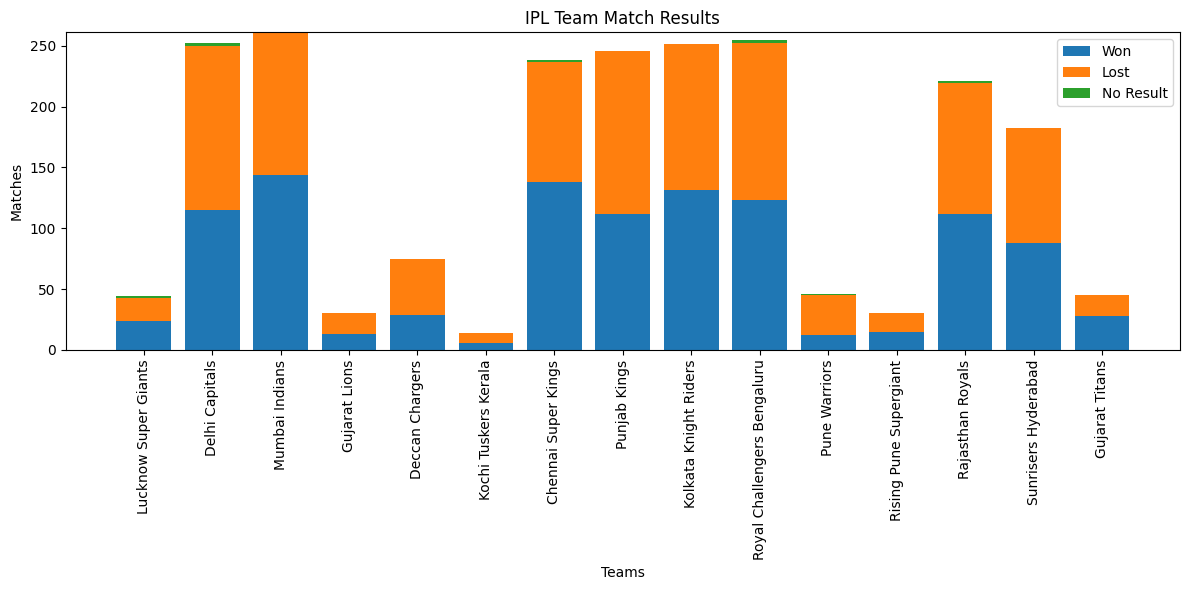

In [31]:
plt.figure(figsize=(12, 6))
plt.bar(team_df["team"], team_df["matches_won"], label="Won")

plt.bar(
    team_df["team"],
    team_df["matches_lost"],
    bottom=team_df["matches_won"],
    label="Lost"
)

plt.bar(
    team_df["team"],
    team_df["matches_with_no_result"],
    bottom=team_df["matches_won"] + team_df["matches_lost"],
    label="No Result"
)

plt.xlabel("Teams")
plt.ylabel("Matches")
plt.title("IPL Team Match Results")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

plt.show()

#### 2. Dates and Season

In [32]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d") # convert date to datatime datatype.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   int64         
 2   city             1044 non-null   object        
 3   date             1095 non-null   datetime64[ns]
 4   match_type       1095 non-null   object        
 5   player_of_match  1090 non-null   object        
 6   venue            1095 non-null   object        
 7   team1            1095 non-null   object        
 8   team2            1095 non-null   object        
 9   toss_winner      1095 non-null   object        
 10  toss_decision    1095 non-null   object        
 11  winner           1090 non-null   object        
 12  result           1095 non-null   object        
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-null   float64

In [34]:
(df['season'] != df['date'].dt.year).sum() 

np.int64(0)

All the matches for a particulare season were played in the same year only. Thus season adds no new information in the dataset.

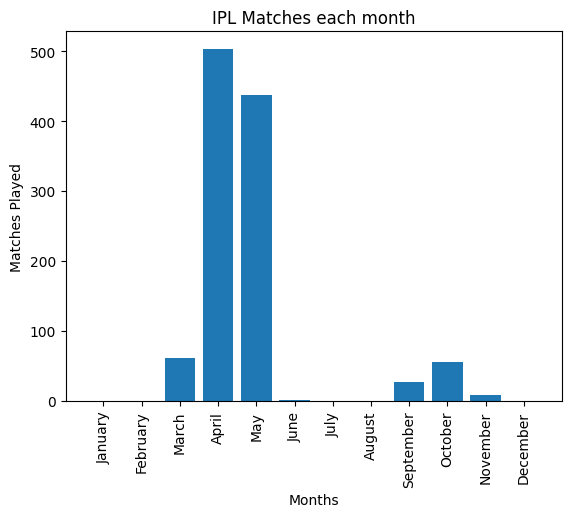

In [35]:
MONTHS = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

month_counts = df['date'].dt.month_name().value_counts().reindex(MONTHS).fillna(0)
plt.bar(month_counts.index, month_counts.values)

plt.xlabel("Months")
plt.ylabel("Matches Played")
plt.title("IPL Matches each month")
plt.xticks(rotation=90)

plt.show()

In [36]:
month_counts

date
January        0.0
February       0.0
March         62.0
April        503.0
May          437.0
June           2.0
July           0.0
August         0.0
September     27.0
October       56.0
November       8.0
December       0.0
Name: count, dtype: float64

In [37]:
(month_counts["March"]+month_counts["April"]+month_counts["May"])/month_counts.sum()

np.float64(0.915068493150685)

So IPL is usually held in March, April an May. A few times matches were conducted later in the year as well, i.e., September, October, November, due to unforeseen situations. But, most of the times, the matches have been conducted in March, April, May only(around 91%).

In [38]:
df.drop("season", axis=1, inplace=True)

In [39]:
# years = sorted(df['date'].dt.year.unique().tolist())
finals = df[df['match_type'] == "Final"]
finals

,id,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
57,336040,Mumbai,2008-06-01,Final,YK Pathan,Dr DY Patil Sports Academy,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3.0,164.0,20.0,N,NaN,BF Bowden,RE Koertzen
114,392239,Johannesburg,2009-05-24,Final,A Kumble,New Wanderers Stadium,Royal Challengers Bengaluru,Deccan Chargers,Royal Challengers Bengaluru,field,Deccan Chargers,runs,6.0,144.0,20.0,N,NaN,RE Koertzen,SJA Taufel
174,419165,Mumbai,2010-04-25,Final,SK Raina,Dr DY Patil Sports Academy,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,Chennai Super Kings,runs,22.0,169.0,20.0,N,NaN,RE Koertzen,SJA Taufel
247,501271,Chennai,2011-05-28,Final,M Vijay,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Royal Challengers Bengaluru,Chennai Super Kings,bat,Chennai Super Kings,runs,58.0,206.0,20.0,N,NaN,Asad Rauf,SJA Taufel
321,548381,Chennai,2012-05-27,Final,MS Bisla,"MA Chidambaram Stadium, Chepauk",Kolkata Knight Riders,Chennai Super Kings,Chennai Super Kings,bat,Kolkata Knight Riders,wickets,5.0,191.0,20.0,N,NaN,BF Bowden,SJA Taufel
397,598073,Kolkata,2013-05-26,Final,KA Pollard,Eden Gardens,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Mumbai Indians,runs,23.0,149.0,20.0,N,NaN,HDPK Dharmasena,SJA Taufel
457,734049,Bangalore,2014-06-01,Final,MK Pandey,M Chinnaswamy Stadium,Kolkata Knight Riders,Punjab Kings,Kolkata Knight Riders,field,Kolkata Knight Riders,wickets,3.0,200.0,20.0,N,NaN,HDPK Dharmasena,BNJ Oxenford
516,829823,Kolkata,2015-05-24,Final,RG Sharma,Eden Gardens,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,Mumbai Indians,runs,41.0,203.0,20.0,N,NaN,HDPK Dharmasena,RK Illingworth
576,981019,Bangalore,2016-05-29,Final,BCJ Cutting,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,8.0,209.0,20.0,N,NaN,HDPK Dharmasena,BNJ Oxenford
635,1082650,Hyderabad,2017-05-21,Final,KH Pandya,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,bat,Mumbai Indians,runs,1.0,130.0,20.0,N,NaN,NJ Llong,S Ravi


In [40]:
finals_each_year = []

for row in finals.itertuples():
    finals_each_year.append({
        "year": row.date.year,
        "winner": row.winner,
        "runner-up": (row.team1 if row.winner == row.team2  else row.team2)
    })

finals_df = pd.DataFrame(finals_each_year).sort_values(by="year")
finals_df

,year,winner,runner-up
0,2008,Rajasthan Royals,Chennai Super Kings
1,2009,Deccan Chargers,Royal Challengers Bengaluru
2,2010,Chennai Super Kings,Mumbai Indians
3,2011,Chennai Super Kings,Royal Challengers Bengaluru
4,2012,Kolkata Knight Riders,Chennai Super Kings
5,2013,Mumbai Indians,Chennai Super Kings
6,2014,Kolkata Knight Riders,Punjab Kings
7,2015,Mumbai Indians,Chennai Super Kings
8,2016,Sunrisers Hyderabad,Royal Challengers Bengaluru
9,2017,Mumbai Indians,Rising Pune Supergiant


#### 3. Venue and City

As seen earlier, there are 51 cities that mising. However, venue has no null values. So let's create a mapping from venue to city to fill the missing values. 

The core idea is that a venue will always be there in the same city. So we'll venues to fill the missing city name from other datapoints.

However, we'll have to check the "venue" feature first.

In [41]:
venues = df['venue'].unique()
venues

array(['M Chinnaswamy Stadium',
       'Punjab Cricket Association Stadium, Mohali', 'Feroz Shah Kotla',
       'Wankhede Stadium', 'Eden Gardens', 'Sawai Mansingh Stadium',
       'Rajiv Gandhi International Stadium, Uppal',
       'MA Chidambaram Stadium, Chepauk', 'Dr DY Patil Sports Academy',
       'Newlands', "St George's Park", 'Kingsmead', 'SuperSport Park',
       'Buffalo Park', 'New Wanderers Stadium', 'De Beers Diamond Oval',
       'OUTsurance Oval', 'Brabourne Stadium',
       'Sardar Patel Stadium, Motera', 'Barabati Stadium',
       'Brabourne Stadium, Mumbai',
       'Vidarbha Cricket Association Stadium, Jamtha',
       'Himachal Pradesh Cricket Association Stadium', 'Nehru Stadium',
       'Holkar Cricket Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Subrata Roy Sahara Stadium',
       'Maharashtra Cricket Association Stadium',
       'Shaheed Veer Narayan Singh International Stadium',
       'JSCA International Stadium Complex', 'Sh

There are many venues that refer to the same stdium, but have been written differently. 

Example: "Eden Gardens, Kolkata" and "Eden Gardens", refer to the same stadium. Similarly, "Feroz Shah Kotla" has been renamed to "Arun Jaitley Stadium". There are many such examples.

Let's fix it.

In [42]:
### Created based on domain knowledge(internet)

venue_mapping = {
    # Chinnaswamy
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",

    # Wankhede
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",

    # Eden Gardens
    "Eden Gardens, Kolkata": "Eden Gardens",

    # MA Chidambaram
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",

    # Arun Jaitley / Feroz Shah Kotla
    "Feroz Shah Kotla": "Arun Jaitley Stadium",
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",

    # Rajiv Gandhi
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad":
        "Rajiv Gandhi International Stadium",

    # Punjab
    "Punjab Cricket Association Stadium, Mohali":
        "Punjab Cricket Association IS Bindra Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali":
        "Punjab Cricket Association IS Bindra Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh":
        "Punjab Cricket Association IS Bindra Stadium",

    # Dr DY Patil
    "Dr DY Patil Sports Academy, Mumbai":
        "Dr DY Patil Sports Academy",

    # Maharashtra
    "Maharashtra Cricket Association Stadium, Pune":
        "Maharashtra Cricket Association Stadium",

    # Narendra Modi Stadium / Motera
    "Sardar Patel Stadium, Motera":
        "Narendra Modi Stadium",
    "Narendra Modi Stadium, Ahmedabad":
        "Narendra Modi Stadium",

    # Zayed
    "Zayed Cricket Stadium, Abu Dhabi":
        "Sheikh Zayed Stadium",

    # Vizag
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam":
        "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium",

    # Jaipur
    "Sawai Mansingh Stadium, Jaipur":
        "Sawai Mansingh Stadium",

    # Dharamsala
    "Himachal Pradesh Cricket Association Stadium, Dharamsala":
        "Himachal Pradesh Cricket Association Stadium",
}

df["venue"] = df["venue"].replace(venue_mapping)

In [43]:
venues = sorted(df['venue'].unique())
print(venues)
print(len(venues)) ## 20 duplicate entries have been removed

['Arun Jaitley Stadium', 'Barabati Stadium', 'Barsapara Cricket Stadium, Guwahati', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow', 'Brabourne Stadium', 'Brabourne Stadium, Mumbai', 'Buffalo Park', 'De Beers Diamond Oval', 'Dr DY Patil Sports Academy', 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium', 'Dubai International Cricket Stadium', 'Eden Gardens', 'Green Park', 'Himachal Pradesh Cricket Association Stadium', 'Holkar Cricket Stadium', 'JSCA International Stadium Complex', 'Kingsmead', 'M Chinnaswamy Stadium', 'MA Chidambaram Stadium', 'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur', 'Maharashtra Cricket Association Stadium', 'Narendra Modi Stadium', 'Nehru Stadium', 'New Wanderers Stadium', 'Newlands', 'OUTsurance Oval', 'Punjab Cricket Association IS Bindra Stadium', 'Rajiv Gandhi International Stadium', 'Saurashtra Cricket Association Stadium', 'Sawai Mansingh Stadium', 'Shaheed Veer Narayan Singh International Stadium', 'Shar

In [44]:
venue_to_city_map = df.groupby("venue")["city"].first().to_dict()
venue_to_city_map

{'Arun Jaitley Stadium': 'Delhi',
 'Barabati Stadium': 'Cuttack',
 'Barsapara Cricket Stadium, Guwahati': 'Guwahati',
 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow': 'Lucknow',
 'Brabourne Stadium': 'Mumbai',
 'Brabourne Stadium, Mumbai': 'Mumbai',
 'Buffalo Park': 'East London',
 'De Beers Diamond Oval': 'Kimberley',
 'Dr DY Patil Sports Academy': 'Mumbai',
 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium': 'Visakhapatnam',
 'Dubai International Cricket Stadium': 'Dubai',
 'Eden Gardens': 'Kolkata',
 'Green Park': 'Kanpur',
 'Himachal Pradesh Cricket Association Stadium': 'Dharamsala',
 'Holkar Cricket Stadium': 'Indore',
 'JSCA International Stadium Complex': 'Ranchi',
 'Kingsmead': 'Durban',
 'M Chinnaswamy Stadium': 'Bangalore',
 'MA Chidambaram Stadium': 'Chennai',
 'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur': 'Mohali',
 'Maharashtra Cricket Association Stadium': 'Pune',
 'Narendra Modi Stadium': 'Ahmedabad',
 'Nehru Stadium'

In [45]:
### use venue_to_city_map to fill empty cities
df["city"] = df["city"].fillna(df["venue"].map(venue_to_city_map))

In [46]:
df["city"].isnull().sum()

np.int64(0)

In [47]:
df.info() ### Here we have successfully filled all the empty cities.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   city             1095 non-null   object        
 2   date             1095 non-null   datetime64[ns]
 3   match_type       1095 non-null   object        
 4   player_of_match  1090 non-null   object        
 5   venue            1095 non-null   object        
 6   team1            1095 non-null   object        
 7   team2            1095 non-null   object        
 8   toss_winner      1095 non-null   object        
 9   toss_decision    1095 non-null   object        
 10  winner           1090 non-null   object        
 11  result           1095 non-null   object        
 12  result_margin    1076 non-null   float64       
 13  target_runs      1092 non-null   float64       
 14  target_overs     1092 non-null   float64

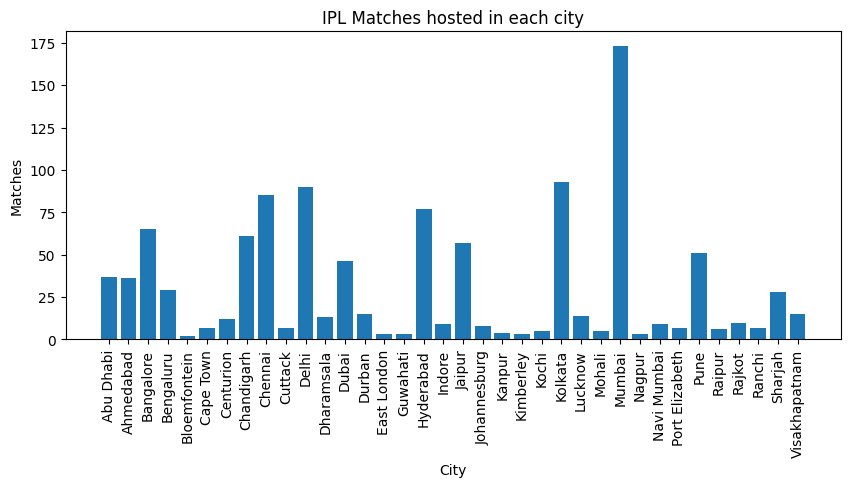

In [48]:
matches_in_each_city = df.groupby("city")["city"].count()

plt.figure(figsize=(10, 4))
plt.bar(matches_in_each_city.index, matches_in_each_city.values)
plt.xlabel("City")
plt.ylabel("Matches")
plt.title("IPL Matches hosted in each city")
plt.xticks(rotation=90)

plt.show()

Mumbai has hosted most IPL matches

#### 4. Impact of toss

In [49]:
df[df["toss_winner"] == df["winner"]]

,id,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
1,335983,Chandigarh,2008-04-19,League,MEK Hussey,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
8,335990,Hyderabad,2008-04-24,League,YK Pathan,Rajiv Gandhi International Stadium,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,3.0,215.0,20.0,N,NaN,Asad Rauf,MR Benson
10,335992,Bangalore,2008-04-26,League,SR Watson,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,7.0,136.0,20.0,N,NaN,MR Benson,IL Howell
12,335994,Mumbai,2008-04-27,League,AC Gilchrist,Dr DY Patil Sports Academy,Mumbai Indians,Deccan Chargers,Deccan Chargers,field,Deccan Chargers,wickets,10.0,155.0,20.0,N,NaN,Asad Rauf,SL Shastri
14,335996,Bangalore,2008-04-28,League,MS Dhoni,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,13.0,179.0,20.0,N,NaN,BR Doctrove,RB Tiffin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1072,1426287,Chennai,2024-05-01,League,Harpreet Brar,MA Chidambaram Stadium,Chennai Super Kings,Punjab Kings,Punjab Kings,field,Punjab Kings,wickets,7.0,163.0,20.0,N,NaN,HAS Khalid,VK Sharma
1073,1426288,Hyderabad,2024-05-02,League,B Kumar,Rajiv Gandhi International Stadium,Sunrisers Hyderabad,Rajasthan Royals,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,1.0,202.0,20.0,N,NaN,AK Chaudhary,YC Barde
1075,1426290,Bengaluru,2024-05-04,League,Mohammed Siraj,M Chinnaswamy Stadium,Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,wickets,4.0,148.0,20.0,N,NaN,A Totre,Vinod Seshan
1078,1426293,Mumbai,2024-05-06,League,SA Yadav,Wankhede Stadium,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,Mumbai Indians,wickets,7.0,174.0,20.0,N,NaN,Navdeep Singh,Tapan Sharma


Since there are 554 matches out of 1095 matches(Approx 50%) where the winner of the toss wins the match, so winning the toss does not imply any unfair advantage.

#### Since result_margin, target_runs, target_overs are the only features that are numeric features, so no point in unncessarily cacluating covariance and correlation.

### Bivariate analysis for features

#### 1. Win percentage of teams at different venues

In [50]:
win_percent_for_each_team = []

for venue in venues:
    venue_matches = df[df["venue"] == venue]

    percentage_wins_for_each_team = {
        "venue": venue,
    }
    
    for team in unique_team_names:
        played = ((venue_matches["team1"] == team) | (venue_matches["team2"] == team)).sum()
        won = (venue_matches["winner"] == team).sum()
        percentage_wins_for_each_team[team] = np.nan if played == 0 else round((won/played * 100), 2)
        
    win_percent_for_each_team.append(percentage_wins_for_each_team)
        
win_percent_for_teams_at_each_venue_df = pd.DataFrame(win_percent_for_each_team).set_index('venue')

#### 2. Win percentage of teams after winning and losing toss

In [51]:
win_percent_based_on_toss = []

for team in unique_team_names:
    played = df[((df["team1"] == team) | (df["team2"] == team))]
    toss_won = played[played["toss_winner"] == team]
    toss_lost = played[played["toss_winner"] != team]

    win_percent_based_on_toss.append({
        "team": team,
        "Match winning% after winning toss": round((toss_won['winner'] == team).sum()/toss_won.shape[0]*100, 2),
        "Match winning% after losing toss": round((toss_lost['winner'] == team).sum()/toss_lost.shape[0]*100, 2),
    })
    
win_percent_based_on_toss_df = pd.DataFrame(win_percent_based_on_toss).set_index('team')
win_percent_based_on_toss_df

,Match winning% after winning toss,Match winning% after losing toss
team,,
Lucknow Super Giants,52.63,56.00
Delhi Capitals,46.92,44.26
Mumbai Indians,54.55,55.93
Gujarat Lions,66.67,20.00
Deccan Chargers,44.19,31.25
Kochi Tuskers Kerala,50.00,33.33
Chennai Super Kings,61.48,54.31
Punjab Kings,41.28,48.91
Kolkata Knight Riders,55.74,48.84


Some teams like "Chennai Super Kings" use winning toss to their advantage and win significantly more matches than that after losing a toss.

A few teams like "Lucknow Super Giants" win more matches after losing toss. This goes to show that teams like these struggle to leverage the toss winning advantage.

#### 3. Win percentage on each venue by batting/fielding first

In [52]:
win_percent = []

for venue in venues:
    venue_matches = df[df["venue"] == venue]
    total = venue_matches.shape[0]

    matches_won_fielding_first = 0
    matches_won_fielding_first += ((venue_matches["toss_decision"] == "field") & (venue_matches["toss_decision"] == venue_matches["winner"])).sum()
    matches_won_fielding_first += ((venue_matches["toss_decision"] == "bat") & (venue_matches["toss_decision"] != venue_matches["winner"]) & (venue_matches["winner"].notna())).sum()

    matches_won_batting_first = 0
    matches_won_batting_first += ((venue_matches["toss_decision"] == "bat") & (venue_matches["toss_decision"] == venue_matches["winner"])).sum()
    matches_won_batting_first += ((venue_matches["toss_decision"] == "field") & (venue_matches["toss_decision"] != venue_matches["winner"]) & (venue_matches["winner"].notna())).sum()
    
    win_percent.append({
        "venue": venue,
        "Winning% batting first": round(matches_won_batting_first/total*100, 2),
        "Winning% fielding first": round(matches_won_fielding_first/total*100, 2),
    })
        
win_percent_at_each_venue_df = pd.DataFrame(win_percent).set_index('venue')
win_percent_at_each_venue_df

,Winning% batting first,Winning% fielding first
venue,,
Arun Jaitley Stadium,60.00,38.89
Barabati Stadium,71.43,28.57
"Barsapara Cricket Stadium, Guwahati",66.67,33.33
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",50.00,42.86
Brabourne Stadium,40.00,60.00
"Brabourne Stadium, Mumbai",82.35,17.65
Buffalo Park,0.00,100.00
De Beers Diamond Oval,33.33,66.67
Dr DY Patil Sports Academy,72.97,27.03


There are some venues like Wankede Stadium, where batting first teams have a higher winning ratio. This usually indicates the pitch slows down as the match progresses, making batting harder later(based on domain knowledge).

There are some venues like Subrata Roy Sahara Stadium, where fielding first teams have a higher winning ratio. This usually indicates the pitch remains good for batting throughout the match and there may be dew in evening games, making it harder for bowlers to grip the ball and easier to bat second(based on domain knowledge).

### Team Performance Clustering
#### Cluster teams based on performance-related metrics to identify groups with similar strengths and weaknesses.

Let's start by preparing dataset

In [53]:
teams_df = pd.merge(team_df, win_percent_based_on_toss_df, on='team').drop(['matches_played', 'matches_won', 'matches_lost', 'matches_with_no_result'], axis=1)
# dropped absolute number of matches, because some newer teams have played lesser number of matches.

In [54]:
# Calcluating winning percentage while batting / fielding first
winning_percentage_batting_and_fielding_first = []

for team in unique_team_names:
    matches = df[(df["team1"] == team) | (df["team2"] == team)]
    played = matches.shape[0]

    matches_won_fielding_first = 0
    matches_won_fielding_first += ((matches["toss_winner"] == team) & (matches["toss_decision"] == "field") & (team == matches["winner"])).sum()
    matches_won_fielding_first += ((matches["toss_winner"] != team) & (matches["toss_decision"] == "bat") & (team == matches["winner"])).sum()

    matches_lost_fielding_first = 0
    matches_lost_fielding_first += ((matches["toss_winner"] == team) & (matches["toss_decision"] == "field") & (team != matches["winner"]) & (matches["winner"].notna())).sum()
    matches_lost_fielding_first += ((matches["toss_winner"] != team) & (matches["toss_decision"] == "bat") & (team != matches["winner"]) & (matches["winner"].notna())).sum()

    
    matches_won_batting_first = 0
    matches_won_batting_first += ((matches["toss_winner"] == team) & (matches["toss_decision"] == "bat") & (team == matches["winner"])).sum()
    matches_won_batting_first += ((matches["toss_winner"] != team) & (matches["toss_decision"] == "field") & (team == matches["winner"])).sum()

    matches_lost_batting_first = 0
    matches_lost_batting_first += ((matches["toss_winner"] == team) & (matches["toss_decision"] == "bat") & (team != matches["winner"]) & (matches["winner"].notna())).sum()
    matches_lost_batting_first += ((matches["toss_winner"] != team) & (matches["toss_decision"] == "field") & (team != matches["winner"]) & (matches["winner"].notna())).sum()
    

    winning_percentage_batting_and_fielding_first.append({
        "team": team,
        "Match winning% batting first": round(matches_won_batting_first/(matches_won_batting_first+matches_lost_batting_first)*100, 2),
        "Match winning% fielding first": round(matches_won_fielding_first/(matches_won_fielding_first+matches_lost_fielding_first)*100, 2),
    })

In [55]:
winning_percentage_batting_and_bowling_first_df = pd.DataFrame(winning_percentage_batting_and_fielding_first)
winning_percentage_batting_and_bowling_first_df

,team,Match winning% batting first,Match winning% fielding first
0,Lucknow Super Giants,72.73,38.10
1,Delhi Capitals,43.24,48.20
2,Mumbai Indians,53.73,56.69
3,Gujarat Lions,7.14,75.00
4,Deccan Chargers,41.86,34.38
5,Kochi Tuskers Kerala,28.57,57.14
6,Chennai Super Kings,53.85,63.55
7,Punjab Kings,39.84,51.69
8,Kolkata Knight Riders,44.17,59.54
9,Royal Challengers Bengaluru,45.31,52.42


In [56]:
teams_df = pd.merge(teams_df, winning_percentage_batting_and_bowling_first_df, on='team')

In [57]:
# Calcluating average victory and losing margin by runs/ wickets
victory_and_losing_margin = []

for team in unique_team_names:
    winning_matches = df[df["winner"] == team]
    losing_matches = df[(((df["team1"] == team) | (df["team2"] == team)) & ((df["winner"].notna()) & (df["winner"] != team)))]

    grouped_winning_matches = winning_matches.groupby('result')['result_margin'].mean()
    grouped_losing_matches = losing_matches.groupby('result')['result_margin'].mean()
    
    victory_and_losing_margin.append({
        "team": team,
        "Avg Victory Margin By Runs": round(grouped_winning_matches['runs'], 2),
        "Avg Victory Margin By Wickets": round(grouped_winning_matches['wickets'], 2),
        "Avg Losing Margin By Runs": round(grouped_losing_matches['runs'], 2),
        "Avg Losing Margin By Wickets": round(grouped_losing_matches['wickets'], 2),
    })

In [58]:
victory_and_losing_margin_df = pd.DataFrame(victory_and_losing_margin)
teams_df = pd.merge(teams_df, victory_and_losing_margin_df, on='team')

In [59]:
# Win percentage at most familiar venues
win_percentage_at_most_familiar_venues = []

for team in unique_team_names:
    matches = df[(df["team1"] == team) | (df["team2"] == team)]
    
    # top 3 venues where a team has played most matches
    familiar_venues = matches.groupby('venue').agg({'id': 'count'}).sort_values(by="id", ascending= False).head(3) 
    matches_played_in_familiar_venue = familiar_venues.sum().values[0]
    familiar_venue_names = familiar_venues.index.to_list()

    # matches won in top 3 most familiar venues
    matches_won_in_familiar_conditions = matches[matches["venue"].isin(familiar_venue_names) & (matches['winner'] == team)].shape[0]

    win_percentage_at_most_familiar_venues.append({
        "team": team,
        "Win% at familiar venues": round(matches_won_in_familiar_conditions/(matches_played_in_familiar_venue)*100, 2),
    })
    
win_percentage_at_most_familiar_venues_df = pd.DataFrame(win_percentage_at_most_familiar_venues)
teams_df = pd.merge(teams_df, win_percentage_at_most_familiar_venues_df, on='team')

In [60]:
teams_df

,team,match_win_percentage,toss_win_percentage,finals_played,title_wins,Match winning% after winning toss,Match winning% after losing toss,Match winning% batting first,Match winning% fielding first,Avg Victory Margin By Runs,Avg Victory Margin By Wickets,Avg Losing Margin By Runs,Avg Losing Margin By Wickets,Win% at familiar venues
0,Lucknow Super Giants,54.55,43.18,0,0,52.63,56.00,72.73,38.10,24.44,5.38,33.23,6.33,56.52
1,Delhi Capitals,45.63,51.59,1,0,46.92,44.26,43.24,48.20,25.63,6.23,33.91,6.00,43.48
2,Mumbai Indians,55.17,54.79,6,5,54.55,55.93,53.73,56.69,32.97,6.20,27.56,6.33,58.26
3,Gujarat Lions,43.33,50.00,0,0,66.67,20.00,7.14,75.00,1.00,5.42,53.50,6.50,35.29
4,Deccan Chargers,38.67,57.33,1,1,44.19,31.25,41.86,34.38,23.39,6.55,25.67,5.92,25.00
5,Kochi Tuskers Kerala,42.86,57.14,0,0,50.00,33.33,28.57,57.14,11.50,7.50,34.67,6.60,50.00
6,Chennai Super Kings,57.98,51.26,10,5,61.48,54.31,53.85,63.55,34.94,6.03,22.79,6.08,65.45
7,Punjab Kings,45.53,44.31,1,0,41.28,48.91,39.84,51.69,24.78,6.21,30.02,6.21,47.31
8,Kolkata Knight Riders,52.19,48.61,4,3,55.74,48.84,44.17,59.54,33.59,6.20,25.83,6.17,51.67
9,Royal Challengers Bengaluru,48.24,47.45,3,0,50.41,46.27,45.31,52.42,34.51,6.53,36.64,6.01,47.11


Our data is ready let's try and visualize it first and then use KMeans to cluster them.

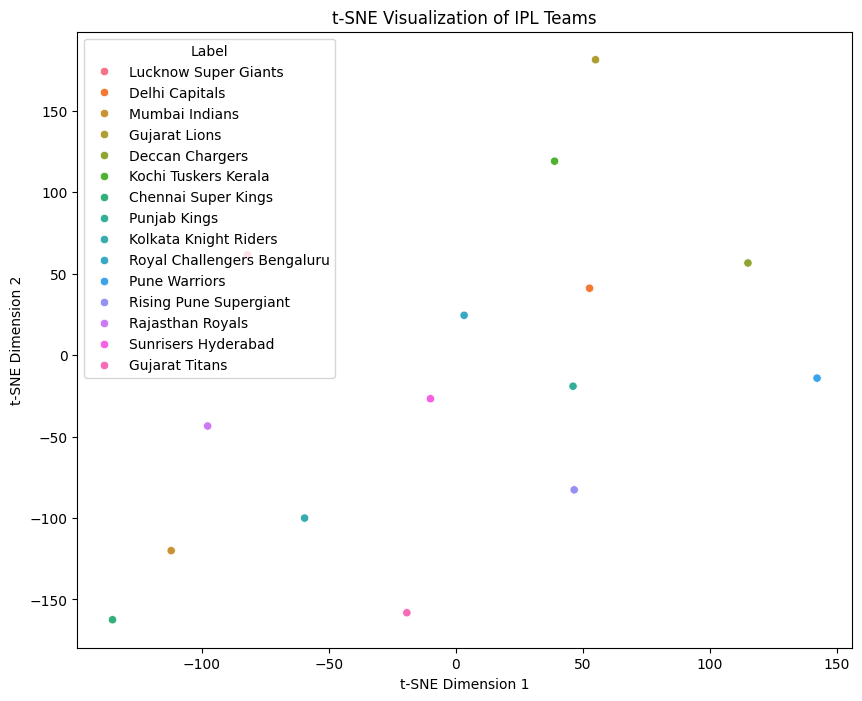

In [61]:
# Visualise using TSNE so that the local structure in higher dimesnions is preserved

X = teams_df.drop(columns=['team'])
y = teams_df['team']

tsne = TSNE(n_components=2,  perplexity=5, random_state=42, max_iter=1000)

# Fit and transform the data
scaler = StandardScaler()
tsne_results = tsne.fit_transform(scaler.fit_transform(X))

# Create a DataFrame for visualization
tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE 1', 't-SNE 2'])
tsne_df['Label'] = y.values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='t-SNE 1', 
    y='t-SNE 2',
    hue='Label',
    data=tsne_df,
    legend='full',
)

plt.title('t-SNE Visualization of IPL Teams')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [62]:
wcss = []
silhouette_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

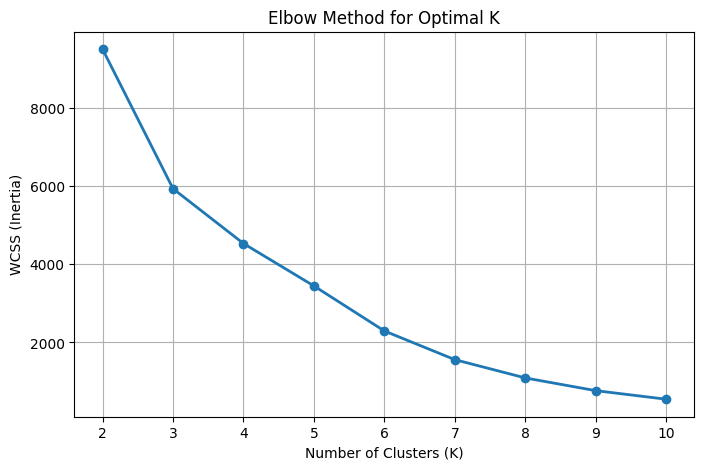

In [63]:
# Plot Elbow Curve

plt.figure(figsize=(8,5))
plt.plot(K, wcss, marker='o', linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.xticks(K)
plt.grid(True)
plt.show()

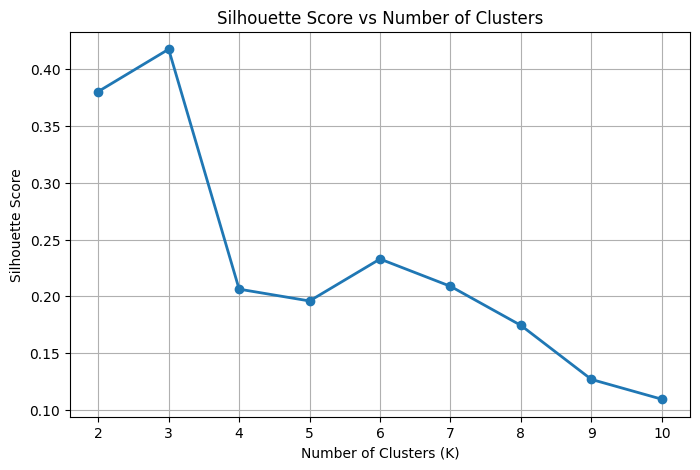

In [64]:
# Plot Silhouette Scores

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker='o', linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(K)
plt.grid(True)
plt.show()

In [65]:
result_df = pd.DataFrame({
    "K": list(K),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
}).set_index("K")

result_df

,WCSS,Silhouette Score
K,,
2,9509.035486,0.380394
3,5936.901636,0.417673
4,4533.094278,0.206351
5,3446.603933,0.195936
6,2293.636917,0.232895
7,1559.056710,0.208852
8,1090.630617,0.174419
9,765.190067,0.126847
10,545.804400,0.109398


#### Let's choose K as 3. 

Reason: The drop from K=2 to K=3 is maxium in elbow method. Also the sillhouette score for K=3 seems to be best.

In [66]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=17,
)

teams_df["Cluster"] = kmeans.fit_predict(X)
print(teams_df[["team", "Cluster"]])

                           team  Cluster
0          Lucknow Super Giants        1
1                Delhi Capitals        2
2                Mumbai Indians        1
3                 Gujarat Lions        2
4               Deccan Chargers        0
5          Kochi Tuskers Kerala        2
6           Chennai Super Kings        1
7                  Punjab Kings        2
8         Kolkata Knight Riders        1
9   Royal Challengers Bengaluru        1
10                Pune Warriors        0
11       Rising Pune Supergiant        2
12             Rajasthan Royals        1
13          Sunrisers Hyderabad        1
14               Gujarat Titans        1


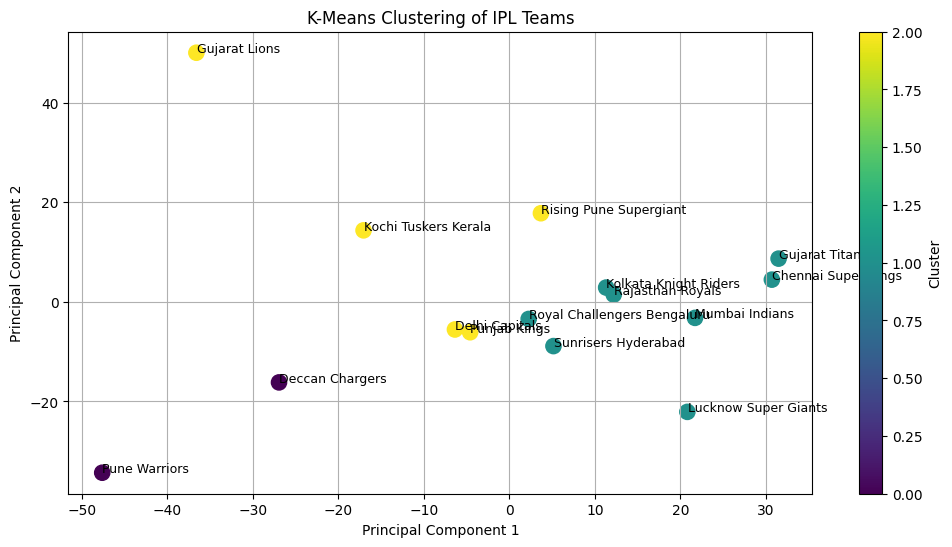

In [67]:
# Reduce to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Scatter plot
plt.figure(figsize=(12,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=teams_df["Cluster"],
    cmap="viridis",
    s=120
)

# Label each point with the team name
for i, team in enumerate(teams_df["team"]):
    plt.text(
        X_pca[i, 0] + 0.03,
        X_pca[i, 1] + 0.03,
        team,
        fontsize=9
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of IPL Teams")

plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()

One cluster has been assigned to very bad performing teams, like Punjab Kings, Delhi Capitals and Kochi Tuskers.

One cluster has been assigned to relatively consistent teams like Mumbai Indians, and Chennai Super Kings.

One cluster has been assigned to discontinued teams.

### Match Outcome Prediction - Logistic Regression
#### Build a Logistic Regression model to predict match winners.

##### Let's define the binary target variable as "team1_win". 

If "team1_win" == 1, then team 1 has won.

If "team1_win" == 0, then team 2 has won.

In [68]:
matches = df[df["winner"].notna()]
matches["team1_win"] = (matches["winner"] == matches["team1"]).astype(int)

/var/folders/5j/psww9n695k3_x9h92m21jtgc0000gn/T/ipykernel_2566/6210608.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matches["team1_win"] = (matches["winner"] == matches["team1"]).astype(int)


In [69]:
matches.head()

,id,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,team1_win
0,335982,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen,0
1,335983,Chandigarh,2008-04-19,League,MEK Hussey,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri,0
2,335984,Delhi,2008-04-19,League,MF Maharoof,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar,1
3,335985,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper,0
4,335986,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan,1


In [70]:
cat_cols = [
    "team1",
    "team2",
    "venue",
    "toss_winner",
    "toss_decision"
]

num_cols = [
    "target_runs",
    "target_overs"
]

We won't use: winner, result, result_margin, player_of_match columns, as these are known after the match and would cause data leakage.

We alo wont use city data, as it would already be captured from venue. So we dont need this redundant data.

In [71]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

X = matches[cat_cols + num_cols]
y = matches["team1_win"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
print(y_train.value_counts(normalize=True)) #classes are close to 50-50, no need to use SMOTE.

team1_win
1    0.509174
0    0.490826
Name: proportion, dtype: float64


In [73]:
X_train_processed = preprocessor.fit_transform(X_train)

In [74]:
# Logistic Regression with L2 regularization
l2_model = LogisticRegression(
    l1_ratio=0,
    solver="liblinear",
    max_iter=1000
)

l2_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [75]:
l1_model = LogisticRegression(
    l1_ratio=1,
    solver="liblinear",
    max_iter=1000
)

l1_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [76]:
lr_no_penalty_model = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=1000
)

lr_no_penalty_model .fit(X_train_processed, y_train)

/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

Logistic Regression with L1 Regularization
Accuracy : 0.5825688073394495
F1       : 0.5991189427312775
ROC-AUC  : 0.6116864528079482


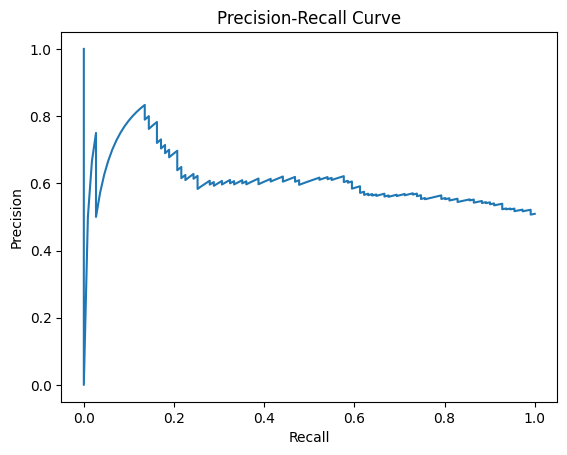

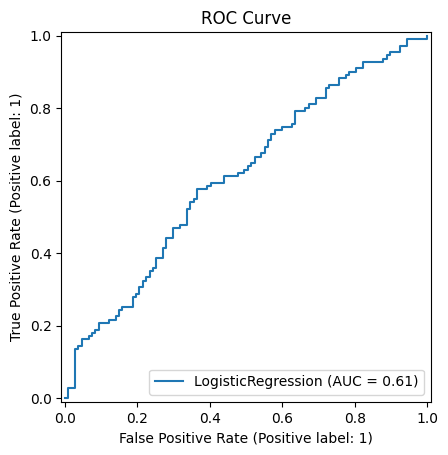


Feature Importance :

Top 10 Features :
                               Feature  Coefficient  Importance
53    cat__venue_New Wanderers Stadium     1.861879    1.861879
19           cat__team2_Gujarat Titans    -0.844076    0.844076
69    cat__toss_winner_Deccan Chargers    -0.797822    0.797822
63         cat__venue_St George's Park    -0.719910    0.719910
62     cat__venue_Sheikh Zayed Stadium    -0.641514    0.641514
24            cat__team2_Pune Warriors     0.622769    0.622769
71      cat__toss_winner_Gujarat Lions    -0.613970    0.613970
9             cat__team1_Pune Warriors    -0.597784    0.597784
31         cat__venue_Barabati Stadium     0.547775    0.547775
61  cat__venue_Sharjah Cricket Stadium    -0.490874    0.490874


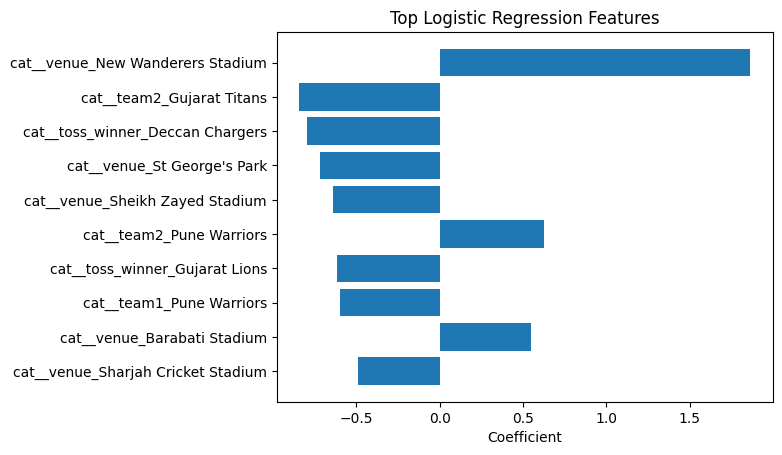

Logistic Regression with L2 Regularization
Accuracy : 0.555045871559633
F1       : 0.5764192139737991
ROC-AUC  : 0.59307906036878


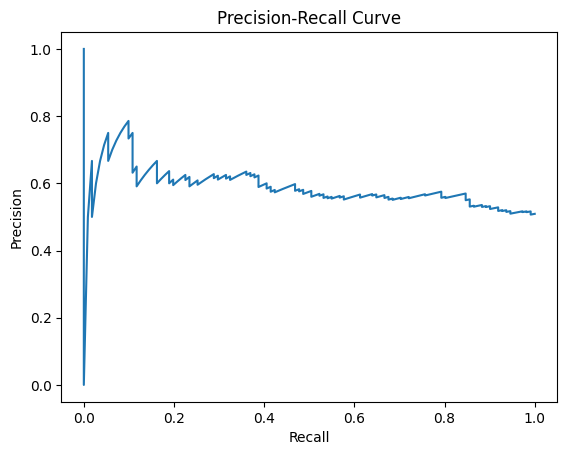

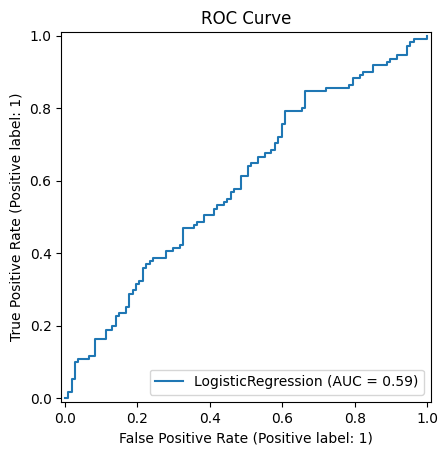


Feature Importance :

Top 10 Features :
                                  Feature  Coefficient  Importance
53       cat__venue_New Wanderers Stadium     1.402058    1.402058
19              cat__team2_Gujarat Titans    -1.024708    1.024708
63            cat__venue_St George's Park    -0.852052    0.852052
31            cat__venue_Barabati Stadium     0.771504    0.771504
62        cat__venue_Sheikh Zayed Stadium    -0.751834    0.751834
69       cat__toss_winner_Deccan Chargers    -0.737279    0.737279
75  cat__toss_winner_Lucknow Super Giants    -0.719676    0.719676
61     cat__venue_Sharjah Cricket Stadium    -0.669494    0.669494
64  cat__venue_Subrata Roy Sahara Stadium    -0.611464    0.611464
24               cat__team2_Pune Warriors     0.605883    0.605883


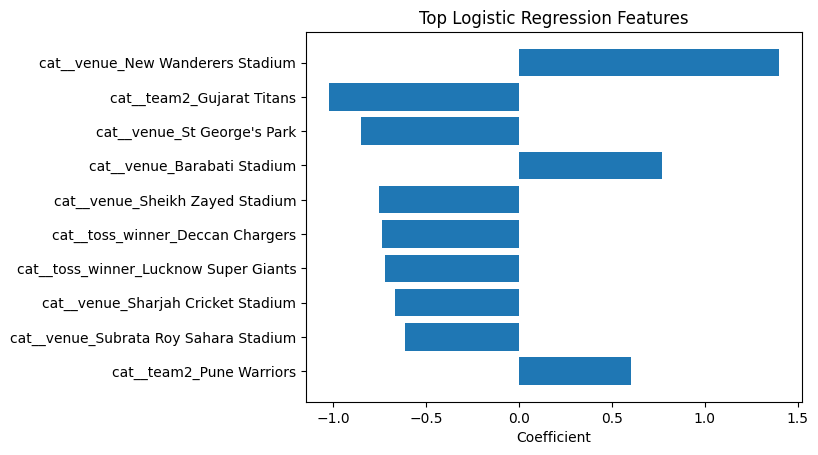

No Regularization
Accuracy : 0.555045871559633
F1       : 0.5688888888888889
ROC-AUC  : 0.5723667592826472


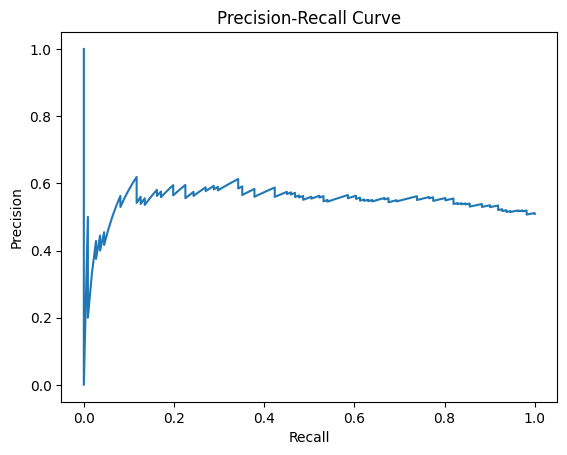

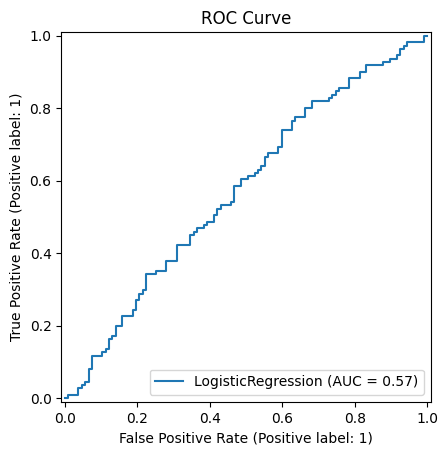


Feature Importance :

Top 10 Features :
                                              Feature  Coefficient  Importance
53                   cat__venue_New Wanderers Stadium    10.215768   10.215768
52                           cat__venue_Nehru Stadium    -6.350091    6.350091
55                         cat__venue_OUTsurance Oval     6.291430    6.291430
5                     cat__team1_Kochi Tuskers Kerala     5.557601    5.557601
3                            cat__team1_Gujarat Lions    -3.587332    3.587332
42                              cat__venue_Green Park     3.560198    3.560198
58  cat__venue_Saurashtra Cricket Association Stadium     2.449822    2.449822
63                        cat__venue_St George's Park    -2.302137    2.302137
19                          cat__team2_Gujarat Titans    -2.176314    2.176314
33  cat__venue_Bharat Ratna Shri Atal Bihari Vajpa...    -1.520966    1.520966


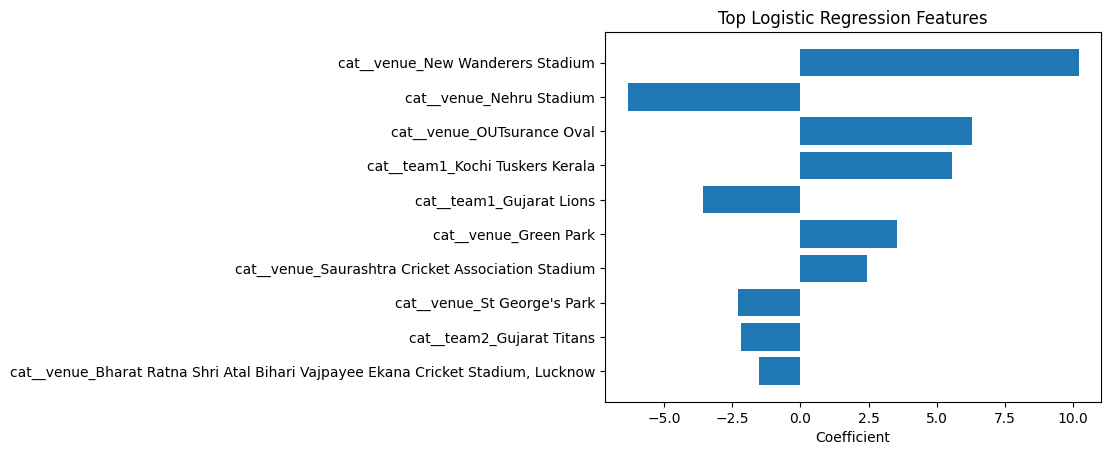

In [77]:
X_test_processed = preprocessor.transform(X_test)

for name, model in [("Logistic Regression with L1 Regularization", l1_model), ("Logistic Regression with L2 Regularization", l2_model), ("No Regularization", lr_no_penalty_model)]:
    pred = model.predict(X_test_processed)
    pred_prob = model.predict_proba(X_test_processed)[:, 1]

    print(name)
    print("Accuracy :", accuracy_score(y_test, pred))
    print("F1       :", f1_score(y_test, pred))
    print("ROC-AUC  :", roc_auc_score(y_test, pred_prob))

    precision, recall, _ = precision_recall_curve(
        y_test,
        pred_prob
    )
    
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()

    RocCurveDisplay.from_estimator(
        model,
        X_test_processed,
        y_test
    )
    plt.title("ROC Curve")
    plt.show()

    print("\nFeature Importance :\n")
    feature_names = preprocessor.get_feature_names_out()
    coef = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model.coef_[0]
    })
    
    coef["Importance"] = coef["Coefficient"].abs()
    
    coef = coef.sort_values(
        "Importance",
        ascending=False
    )

    top_features = coef.head(10)
    print("Top 10 Features :")
    print(top_features)

    plt.barh(
        top_features["Feature"],
        top_features["Coefficient"]
    )
    
    plt.gca().invert_yaxis()
    plt.xlabel("Coefficient")
    plt.title("Top Logistic Regression Features")
    plt.show()
    
    print("="*100)

### Performance Trend Analysis

In [78]:
import pandas as pd

records = []
# Convert the match-level data into one row per team per season.
for _, row in df.iterrows():
    season = row["date"].year

    for team in [row["team1"], row["team2"]]:
        opponent = row["team2"] if team == row["team1"] else row["team1"]
        won = int(row["winner"] == team)
        toss_win = int(row["toss_winner"] == team)

        records.append({
            "Season": season,
            "Team": team,
            "Opponent": opponent,
            "Won": won,
            "TossWon": toss_win,
            "Venue": row["venue"]
        })

team_season = pd.DataFrame(records)

In [79]:
team_season

,Season,Team,Opponent,Won,TossWon,Venue
0,2008,Royal Challengers Bengaluru,Kolkata Knight Riders,0,1,M Chinnaswamy Stadium
1,2008,Kolkata Knight Riders,Royal Challengers Bengaluru,1,0,M Chinnaswamy Stadium
2,2008,Punjab Kings,Chennai Super Kings,0,0,Punjab Cricket Association IS Bindra Stadium
3,2008,Chennai Super Kings,Punjab Kings,1,1,Punjab Cricket Association IS Bindra Stadium
4,2008,Delhi Capitals,Rajasthan Royals,1,0,Arun Jaitley Stadium
...,...,...,...,...,...,...
2185,2024,Rajasthan Royals,Royal Challengers Bengaluru,1,1,Narendra Modi Stadium
2186,2024,Sunrisers Hyderabad,Rajasthan Royals,1,0,MA Chidambaram Stadium
2187,2024,Rajasthan Royals,Sunrisers Hyderabad,0,1,MA Chidambaram Stadium
2188,2024,Sunrisers Hyderabad,Kolkata Knight Riders,0,1,MA Chidambaram Stadium


In [80]:
season_stats = (
    team_season
    .groupby(["Season","Team"])
    .agg(
        Matches=("Won","count"),
        Wins=("Won","sum"),
        TossWins=("TossWon","sum")
    )
    .reset_index()
)

season_stats["Win%"] = (
    season_stats["Wins"] /
    season_stats["Matches"] * 100
)

season_stats["TossWin%"] = (
    season_stats["TossWins"] /
    season_stats["Matches"] * 100
)

In [81]:
season_stats.head()

,Season,Team,Matches,Wins,TossWins,Win%,TossWin%
0,2008,Chennai Super Kings,16,9,5,56.250000,31.250000
1,2008,Deccan Chargers,14,2,9,14.285714,64.285714
2,2008,Delhi Capitals,14,7,6,50.000000,42.857143
3,2008,Kolkata Knight Riders,13,6,6,46.153846,46.153846
4,2008,Mumbai Indians,14,7,8,50.000000,57.142857


In [82]:
# Difference between Toss Win % and Match Win %
    # Positive value → won tosses more than matches
    # Negative value → won more matches than tosses

season_stats["TossLuck"] = (
    season_stats["TossWin%"] -
    season_stats["Win%"]
)
season_stats.head()

,Season,Team,Matches,Wins,TossWins,Win%,TossWin%,TossLuck
0,2008,Chennai Super Kings,16,9,5,56.250000,31.250000,-25.000000
1,2008,Deccan Chargers,14,2,9,14.285714,64.285714,50.000000
2,2008,Delhi Capitals,14,7,6,50.000000,42.857143,-7.142857
3,2008,Kolkata Knight Riders,13,6,6,46.153846,46.153846,0.000000
4,2008,Mumbai Indians,14,7,8,50.000000,57.142857,7.142857


In [83]:
# Find each team's top 3 venues overall.

top3 = (
    team_season
    .groupby(["Team","Venue"])
    .size()
    .reset_index(name="Matches")
    .sort_values(["Team","Matches"], ascending=False)
    .groupby("Team")
    .head(3)
)

top3_dict = (
    top3.groupby("Team")["Venue"]
    .apply(set)
    .to_dict()
)

team_season["TopVenue"] = team_season.apply(
    lambda x: x["Venue"] in top3_dict[x["Team"]],
    axis=1
)

venue_exp = (
    team_season
    .groupby(["Season","Team"])
    .agg(
        TopVenueMatches=("TopVenue","sum"),
        Matches=("Won","count")
    )
    .reset_index()
)

venue_exp["VenueExposure"] = (
    venue_exp["TopVenueMatches"] /
    venue_exp["Matches"]
)

In [84]:
venue_exp

,Season,Team,TopVenueMatches,Matches,VenueExposure
0,2008,Chennai Super Kings,9,16,0.562500
1,2008,Deccan Chargers,9,14,0.642857
2,2008,Delhi Capitals,7,14,0.500000
3,2008,Kolkata Knight Riders,9,13,0.692308
4,2008,Mumbai Indians,6,14,0.428571
...,...,...,...,...,...
141,2024,Mumbai Indians,8,14,0.571429
142,2024,Punjab Kings,1,14,0.071429
143,2024,Rajasthan Royals,7,15,0.466667
144,2024,Royal Challengers Bengaluru,9,15,0.600000


In [85]:
win_lookup = season_stats.set_index(
    ["Season","Team"]
)["Win%"]

win_lookup

Season  Team                       
2008    Chennai Super Kings            56.250000
        Deccan Chargers                14.285714
        Delhi Capitals                 50.000000
        Kolkata Knight Riders          46.153846
        Mumbai Indians                 50.000000
                                         ...    
2024    Mumbai Indians                 28.571429
        Punjab Kings                   35.714286
        Rajasthan Royals               60.000000
        Royal Challengers Bengaluru    46.666667
        Sunrisers Hyderabad            56.250000
Name: Win%, Length: 146, dtype: float64

In [86]:
team_season["OpponentStrength"] = team_season.apply(
    lambda x: win_lookup.get(
        (x["Season"], x["Opponent"]),
        50
    ),
    axis=1
)

opp_strength = (
    team_season
    .groupby(["Season","Team"])
    .OpponentStrength
    .mean()
    .reset_index()
)

In [87]:
team_season

,Season,Team,Opponent,Won,TossWon,Venue,TopVenue,OpponentStrength
0,2008,Royal Challengers Bengaluru,Kolkata Knight Riders,0,1,M Chinnaswamy Stadium,True,46.153846
1,2008,Kolkata Knight Riders,Royal Challengers Bengaluru,1,0,M Chinnaswamy Stadium,True,28.571429
2,2008,Punjab Kings,Chennai Super Kings,0,0,Punjab Cricket Association IS Bindra Stadium,True,56.250000
3,2008,Chennai Super Kings,Punjab Kings,1,1,Punjab Cricket Association IS Bindra Stadium,False,66.666667
4,2008,Delhi Capitals,Rajasthan Royals,1,0,Arun Jaitley Stadium,True,81.250000
...,...,...,...,...,...,...,...,...
2185,2024,Rajasthan Royals,Royal Challengers Bengaluru,1,1,Narendra Modi Stadium,True,46.666667
2186,2024,Sunrisers Hyderabad,Rajasthan Royals,1,0,MA Chidambaram Stadium,False,60.000000
2187,2024,Rajasthan Royals,Sunrisers Hyderabad,0,1,MA Chidambaram Stadium,False,56.250000
2188,2024,Sunrisers Hyderabad,Kolkata Knight Riders,0,1,MA Chidambaram Stadium,False,78.571429


In [88]:
opp_strength

,Season,Team,OpponentStrength
0,2008,Chennai Super Kings,51.360749
1,2008,Deccan Chargers,54.127420
2,2008,Delhi Capitals,51.532248
3,2008,Kolkata Knight Riders,49.542125
4,2008,Mumbai Indians,49.025379
...,...,...,...
141,2024,Mumbai Indians,54.549320
142,2024,Punjab Kings,51.164966
143,2024,Rajasthan Royals,46.976190
144,2024,Royal Challengers Bengaluru,51.531746


In [89]:
trend_analysis_df = season_stats.merge(
    venue_exp[["Season","Team","VenueExposure"]],
    on=["Season","Team"]
)

trend_analysis_df = trend_analysis_df.merge(
    opp_strength,
    on=["Season","Team"]
)

trend_analysis_df.head()

,Season,Team,Matches,Wins,TossWins,Win%,TossWin%,TossLuck,VenueExposure,OpponentStrength
0,2008,Chennai Super Kings,16,9,5,56.250000,31.250000,-25.000000,0.562500,51.360749
1,2008,Deccan Chargers,14,2,9,14.285714,64.285714,50.000000,0.642857,54.127420
2,2008,Delhi Capitals,14,7,6,50.000000,42.857143,-7.142857,0.500000,51.532248
3,2008,Kolkata Knight Riders,13,6,6,46.153846,46.153846,0.000000,0.692308,49.542125
4,2008,Mumbai Indians,14,7,8,50.000000,57.142857,7.142857,0.428571,49.025379


In [90]:
# Let's try and fit a linear regression model
X = trend_analysis_df[[
    "Season",
    "TossLuck",
    "VenueExposure",
    "OpponentStrength"
]]

y = trend_analysis_df["Win%"]

model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [91]:
# Predict Next Season
next_season = trend_analysis_df.copy()
next_season["Season"] += 1

next_season["PredictedWin%"] = model.predict(
    next_season[[
        "Season",
        "TossLuck",
        "VenueExposure",
        "OpponentStrength"
    ]]
)

In [92]:
next_season

,Season,Team,Matches,Wins,TossWins,Win%,TossWin%,TossLuck,VenueExposure,OpponentStrength,PredictedWin%
0,2009,Chennai Super Kings,16,9,5,56.250000,31.250000,-25.000000,0.562500,51.360749,52.977504
1,2009,Deccan Chargers,14,2,9,14.285714,64.285714,50.000000,0.642857,54.127420,13.629406
2,2009,Delhi Capitals,14,7,6,50.000000,42.857143,-7.142857,0.500000,51.532248,45.610615
3,2009,Kolkata Knight Riders,13,6,6,46.153846,46.153846,0.000000,0.692308,49.542125,50.054290
4,2009,Mumbai Indians,14,7,8,50.000000,57.142857,7.142857,0.428571,49.025379,49.779384
...,...,...,...,...,...,...,...,...,...,...,...
141,2025,Mumbai Indians,14,4,10,28.571429,71.428571,42.857143,0.571429,54.549320,14.500836
142,2025,Punjab Kings,14,5,10,35.714286,71.428571,35.714286,0.071429,51.164966,31.011794
143,2025,Rajasthan Royals,15,9,11,60.000000,73.333333,13.333333,0.466667,46.976190,54.704977
144,2025,Royal Challengers Bengaluru,15,7,8,46.666667,53.333333,6.666667,0.600000,51.531746,39.737205


In [93]:
# Instead of fitting one model for all teams, let's fit one regression per team to estimate its trend over time.
trends = []

for team in unique_team_names:

    team_matches = trend_analysis_df[trend_analysis_df.Team==team]

    X = team_matches[["Season"]]
    y = team_matches["Win%"]

    model = LinearRegression()
    model.fit(X,y)
    slope = model.coef_[0]

    next_season = pd.DataFrame({
        "Season": [team_matches["Season"].max() + 1]
    })
    prediction = model.predict(next_season)[0]

    trends.append({
        "Team":team,
        "Slope":slope,
        "NextSeasonPrediction":prediction
    })

trend_df = pd.DataFrame(trends)
trend_df.sort_values("Slope", ascending=False)

,Team,Slope,NextSeasonPrediction
11,Rising Pune Supergiant,26.785714,89.285714
4,Deccan Chargers,1.136905,41.422619
8,Kolkata Knight Riders,0.647320,57.541520
1,Delhi Capitals,0.248888,47.376825
9,Royal Challengers Bengaluru,0.061521,48.206677
5,Kochi Tuskers Kerala,0.000000,42.857143
12,Rajasthan Royals,-0.456671,45.929636
6,Chennai Super Kings,-0.594050,52.093330
7,Punjab Kings,-0.690325,38.835681
2,Mumbai Indians,-0.758134,47.321556


#### Interpretation:

##### Positive slope → improving team
##### Negative slope → declining team
##### Near zero → stable performance

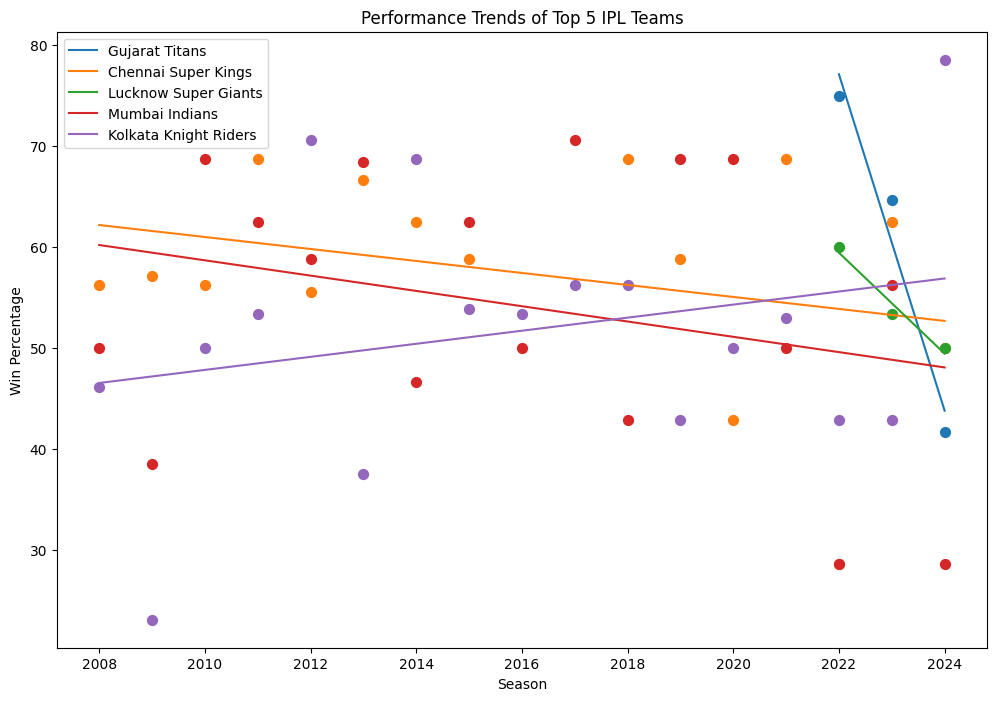

In [94]:
### Visualization for Top 5 Teams

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

top5 = (
    season_stats.groupby("Team")["Win%"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12,8))

for team in top5:

    temp = trend_analysis_df[trend_analysis_df.Team==team]

    X = temp["Season"].values.reshape(-1,1)

    y = temp["Win%"]

    model = LinearRegression()
    model.fit(X,y)

    plt.scatter(
        temp["Season"],
        y,
        s=50
    )

    x = np.linspace(
        temp.Season.min(),
        temp.Season.max(),
        100
    )

    plt.plot(
        x,
        model.predict(x.reshape(-1,1)),
        label=team
    )

plt.legend()
plt.xlabel("Season")
plt.ylabel("Win Percentage")
plt.title("Performance Trends of Top 5 IPL Teams")

plt.show()

In [95]:
trend_df["Trend"] = trend_df["Slope"].apply(
    lambda s: "Improving" if s > 0.5
    else ("Declining" if s < -0.5 else "Stable")
)

print(trend_df.sort_values("Slope", ascending=False))

                           Team      Slope  NextSeasonPrediction      Trend
11       Rising Pune Supergiant  26.785714             89.285714  Improving
4               Deccan Chargers   1.136905             41.422619  Improving
8         Kolkata Knight Riders   0.647320             57.541520  Improving
1                Delhi Capitals   0.248888             47.376825     Stable
9   Royal Challengers Bengaluru   0.061521             48.206677     Stable
5          Kochi Tuskers Kerala   0.000000             42.857143     Stable
12             Rajasthan Royals  -0.456671             45.929636     Stable
6           Chennai Super Kings  -0.594050             52.093330  Declining
7                  Punjab Kings  -0.690325             38.835681  Declining
2                Mumbai Indians  -0.758134             47.321556  Declining
13          Sunrisers Hyderabad  -1.620695             37.087153  Declining
10                Pune Warriors  -1.785714             22.619048  Declining
0          L

### Player of the Match Prediction — KNN

In [96]:
y = df["player_of_match"]
matches = df[df["player_of_match"].notna()].copy()

#### Let's build match‑context features:

In [97]:
### 1. Venue Chasing Bias: Percentage of matches won while chasing at a venue.
venue_stats = []

for venue, grp in matches.groupby("venue"):

    chasing_wins = 0

    for _, row in grp.iterrows():

        # Identify chasing team
        if row["toss_decision"] == "bat":
            chasing_team = row["team2"] if row["toss_winner"] == row["team1"] else row["team1"]
        else:
            chasing_team = row["toss_winner"]

        if row["winner"] == chasing_team:
            chasing_wins += 1

    venue_stats.append({
        "venue": venue,
        "VenueChasingBias": chasing_wins / len(grp)
    })

venue_bias = pd.DataFrame(venue_stats)
matches = matches.merge(venue_bias, on="venue")

In [98]:
### 2. Average First Innings Proxy: Since we don't have ball-by-ball data, use the target.

avg_target = (
    matches
    .groupby("venue")["target_runs"]
    .mean()
    .rename("AvgTarget")
)

matches = matches.merge(
    avg_target,
    on="venue"
)

In [99]:
### 3. Shortened Match Flag

matches["ShortenedMatch"] = (
    matches["method"].notna()
).astype(int)

In [100]:
### 4. Rolling percentae wins

matches = matches.sort_values("date")
team_strength = {}

recent_team_strength = []

for _, row in matches.iterrows():

    season = row.date.year

    for team in [row["team1"], row["team2"]]:

        if team not in team_strength:
            team_strength[team] = []

    team1_recent = np.mean(team_strength[row["team1"]][-5:]) if team_strength[row["team1"]] else 0.5
    team2_recent = np.mean(team_strength[row["team2"]][-5:]) if team_strength[row["team2"]] else 0.5

    recent_team_strength.append((team1_recent, team2_recent))

    team_strength[row["team1"]].append(int(row["winner"] == row["team1"]))
    team_strength[row["team2"]].append(int(row["winner"] == row["team2"]))

matches["Team1RecentWinPct"] = [x[0] for x in recent_team_strength]
matches["Team2RecentWinPct"] = [x[1] for x in recent_team_strength]

In [101]:
### 5. Historical counts only from previous matches.

### Player of the match by Venue
matches["PoMVenueCount"] = 0
history = {}

for i, row in matches.iterrows():
    key = (row["player_of_match"], row["venue"])
    matches.at[i, "PoMVenueCount"] = history.get(key, 0)
    history[key] = history.get(key, 0) + 1

### Player of the match by Opponent
matches["Opponent"] = np.where(
    matches["winner"] == matches["team1"],
    matches["team2"],
    matches["team1"]
)

matches["PoMOpponentCount"] = 0
history = {}

for i, row in matches.iterrows():
    key = (row["player_of_match"], row["Opponent"])
    matches.at[i, "PoMOpponentCount"] = history.get(key, 0)
    history[key] = history.get(key, 0) + 1

### Player of the match by season
matches["PoMSeasonCount"] = 0

history = {}

for i, row in matches.iterrows():

    key = (
        row["player_of_match"],
        row.date.year
    )
    matches.at[i, "PoMSeasonCount"] = history.get(key, 0)
    history[key] = history.get(key, 0) + 1

#### Let's Build Feature Matrix

In [102]:
feature_cols = [
    "VenueChasingBias",
    "AvgTarget",
    "ShortenedMatch",
    "Team1RecentWinPct",
    "Team2RecentWinPct",
    "PoMVenueCount",
    "PoMOpponentCount",
    "PoMSeasonCount"
]

X = matches[feature_cols]
y = matches["player_of_match"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [103]:
params = {
    "n_neighbors": range(3,21)
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_scaled, y)

print(grid.best_params_) # Optimal number of nearest neighbours for using KNN model

{'n_neighbors': 6}


/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [104]:
knn = KNeighborsClassifier(
    n_neighbors=grid.best_params_["n_neighbors"]
)

knn.fit(X_scaled, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Let's Predict Top-k Candidates

In [105]:
distances, indices = knn.kneighbors(
    X_scaled,
    n_neighbors=5
)

In [106]:
### Checking for a particular match, i.e., match 0
match = 0
neighbors = matches.iloc[
    indices[match]
]

print(neighbors[
    [
        "player_of_match",
        "venue",
        "winner"
    ]
])

    player_of_match                  venue                       winner
0       BB McCullum  M Chinnaswamy Stadium        Kolkata Knight Riders
875  Mohammed Shami       Wankhede Stadium               Gujarat Titans
132      RV Uthappa  M Chinnaswamy Stadium  Royal Challengers Bengaluru
288   Azhar Mahmood  M Chinnaswamy Stadium                 Punjab Kings
182    SR Tendulkar  M Chinnaswamy Stadium               Mumbai Indians


In [107]:
votes = Counter(
    neighbors["player_of_match"]
)

print(votes.most_common())

[('BB McCullum', 1), ('Mohammed Shami', 1), ('RV Uthappa', 1), ('Azhar Mahmood', 1), ('SR Tendulkar', 1)]


#### Plot validation accuracy versus k

/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/opt/homebrew/Cellar/jupyterlab/4.5.0_2/libexec/lib/python3.14/site-packages/sklearn/mod

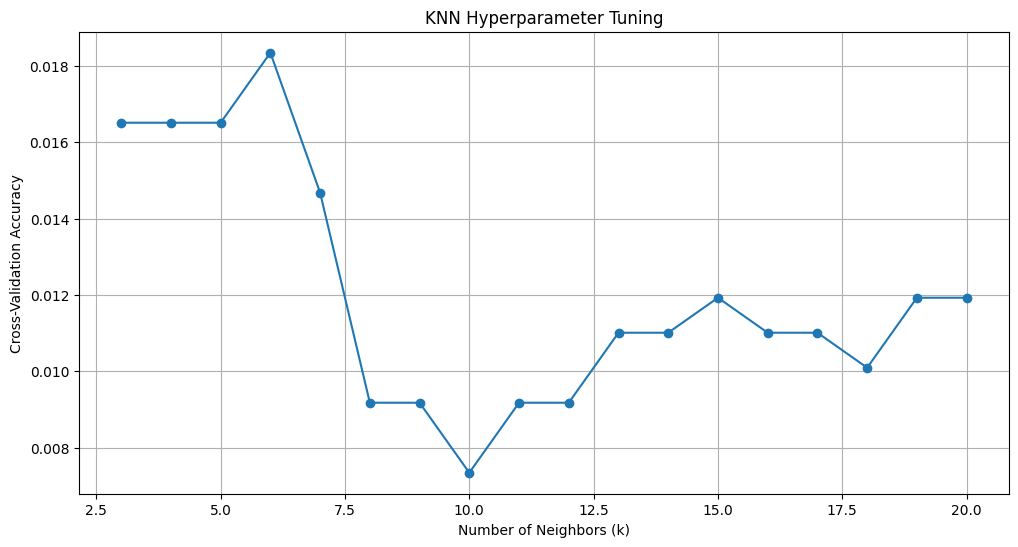

In [108]:
scores = []

for k in range(3,21):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    score = cross_val_score(
        model,
        X_scaled,
        y,
        cv=5
    ).mean()

    scores.append(score)

plt.figure(figsize=(12,6))
plt.plot(range(3,21), scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("KNN Hyperparameter Tuning")
plt.grid(True)
plt.show()

### Toss Decision Strategy - Decision Tree

In [109]:
### 1. Create the Target Variable
matches = df[df["winner"].notna()].copy()

matches["OptimalDecision"] = np.where(
    matches["winner"] == matches["toss_winner"],
    matches["toss_decision"],
    np.where(matches["toss_decision"]=="bat","field","bat")
)

In [110]:
### 2. Feature Engineering

### Venue History
venue_stats = (
    matches
    .groupby("venue")
    .agg(
        TotalMatches=("id","count"),
        BatWins=(
            "OptimalDecision",
            lambda x: (x=="bat").sum()
        ),
        FieldWins=(
            "OptimalDecision",
            lambda x: (x=="field").sum()
        )
    )
)

venue_stats["VenueBatBias"] = (
    venue_stats["BatWins"] /
    venue_stats["TotalMatches"]
)

venue_stats["VenueFieldBias"] = (
    venue_stats["FieldWins"] /
    venue_stats["TotalMatches"]
)

matches = matches.merge(
    venue_stats[
        ["VenueBatBias","VenueFieldBias"]
    ],
    left_on="venue",
    right_index=True
)

### Weather conditions(Synthetically created, since this data is not available
np.random.seed(42)

matches["Temperature"] = np.random.normal(
    30,
    3,
    len(matches)
)

matches["Humidity"] = np.random.uniform(
    40,
    90,
    len(matches)
)

matches["Dew"] = (
    matches["Humidity"] > 70
).astype(int)


### Team Strength
team_strength = {}

for team in pd.concat(
    [matches.team1,matches.team2]
).unique():

    played = (
        (matches.team1==team) |
        (matches.team2==team)
    ).sum()

    wins = (
        matches.winner==team
    ).sum()

    team_strength[team] = wins/played
    
matches["Team1Strength"] = (
    matches.team1.map(team_strength)
)

matches["Team2Strength"] = (
    matches.team2.map(team_strength)
)

matches["StrengthDifference"] = (
    matches["Team1Strength"] -
    matches["Team2Strength"]
)

In [111]:
### Match Importance
matches["MatchImportance"] = np.where(
    matches["match_type"]=="League",
    "League",
    "Playoff"
)

In [112]:
### 3. Create feature encodings

cat_cols = [
    "venue",
    "MatchImportance"
]

num_cols = [
    "VenueBatBias",
    "VenueFieldBias",
    "Temperature",
    "Humidity",
    "Dew",
    "StrengthDifference"
]

preprocessor = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        )
    ],
    remainder="passthrough"
)

In [113]:
### 4. Train-test split

X = matches[
    cat_cols+num_cols
]

y = matches["OptimalDecision"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=.2,
    random_state=42,
    stratify=y
)

In [114]:
### 5. Fit decision tree

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(
    X_train_enc,
    y_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [115]:
### 6. Evaluating model

pred = tree.predict(X_test_enc)

print(
    accuracy_score(
        y_test,
        pred
    )
)

0.4908256880733945


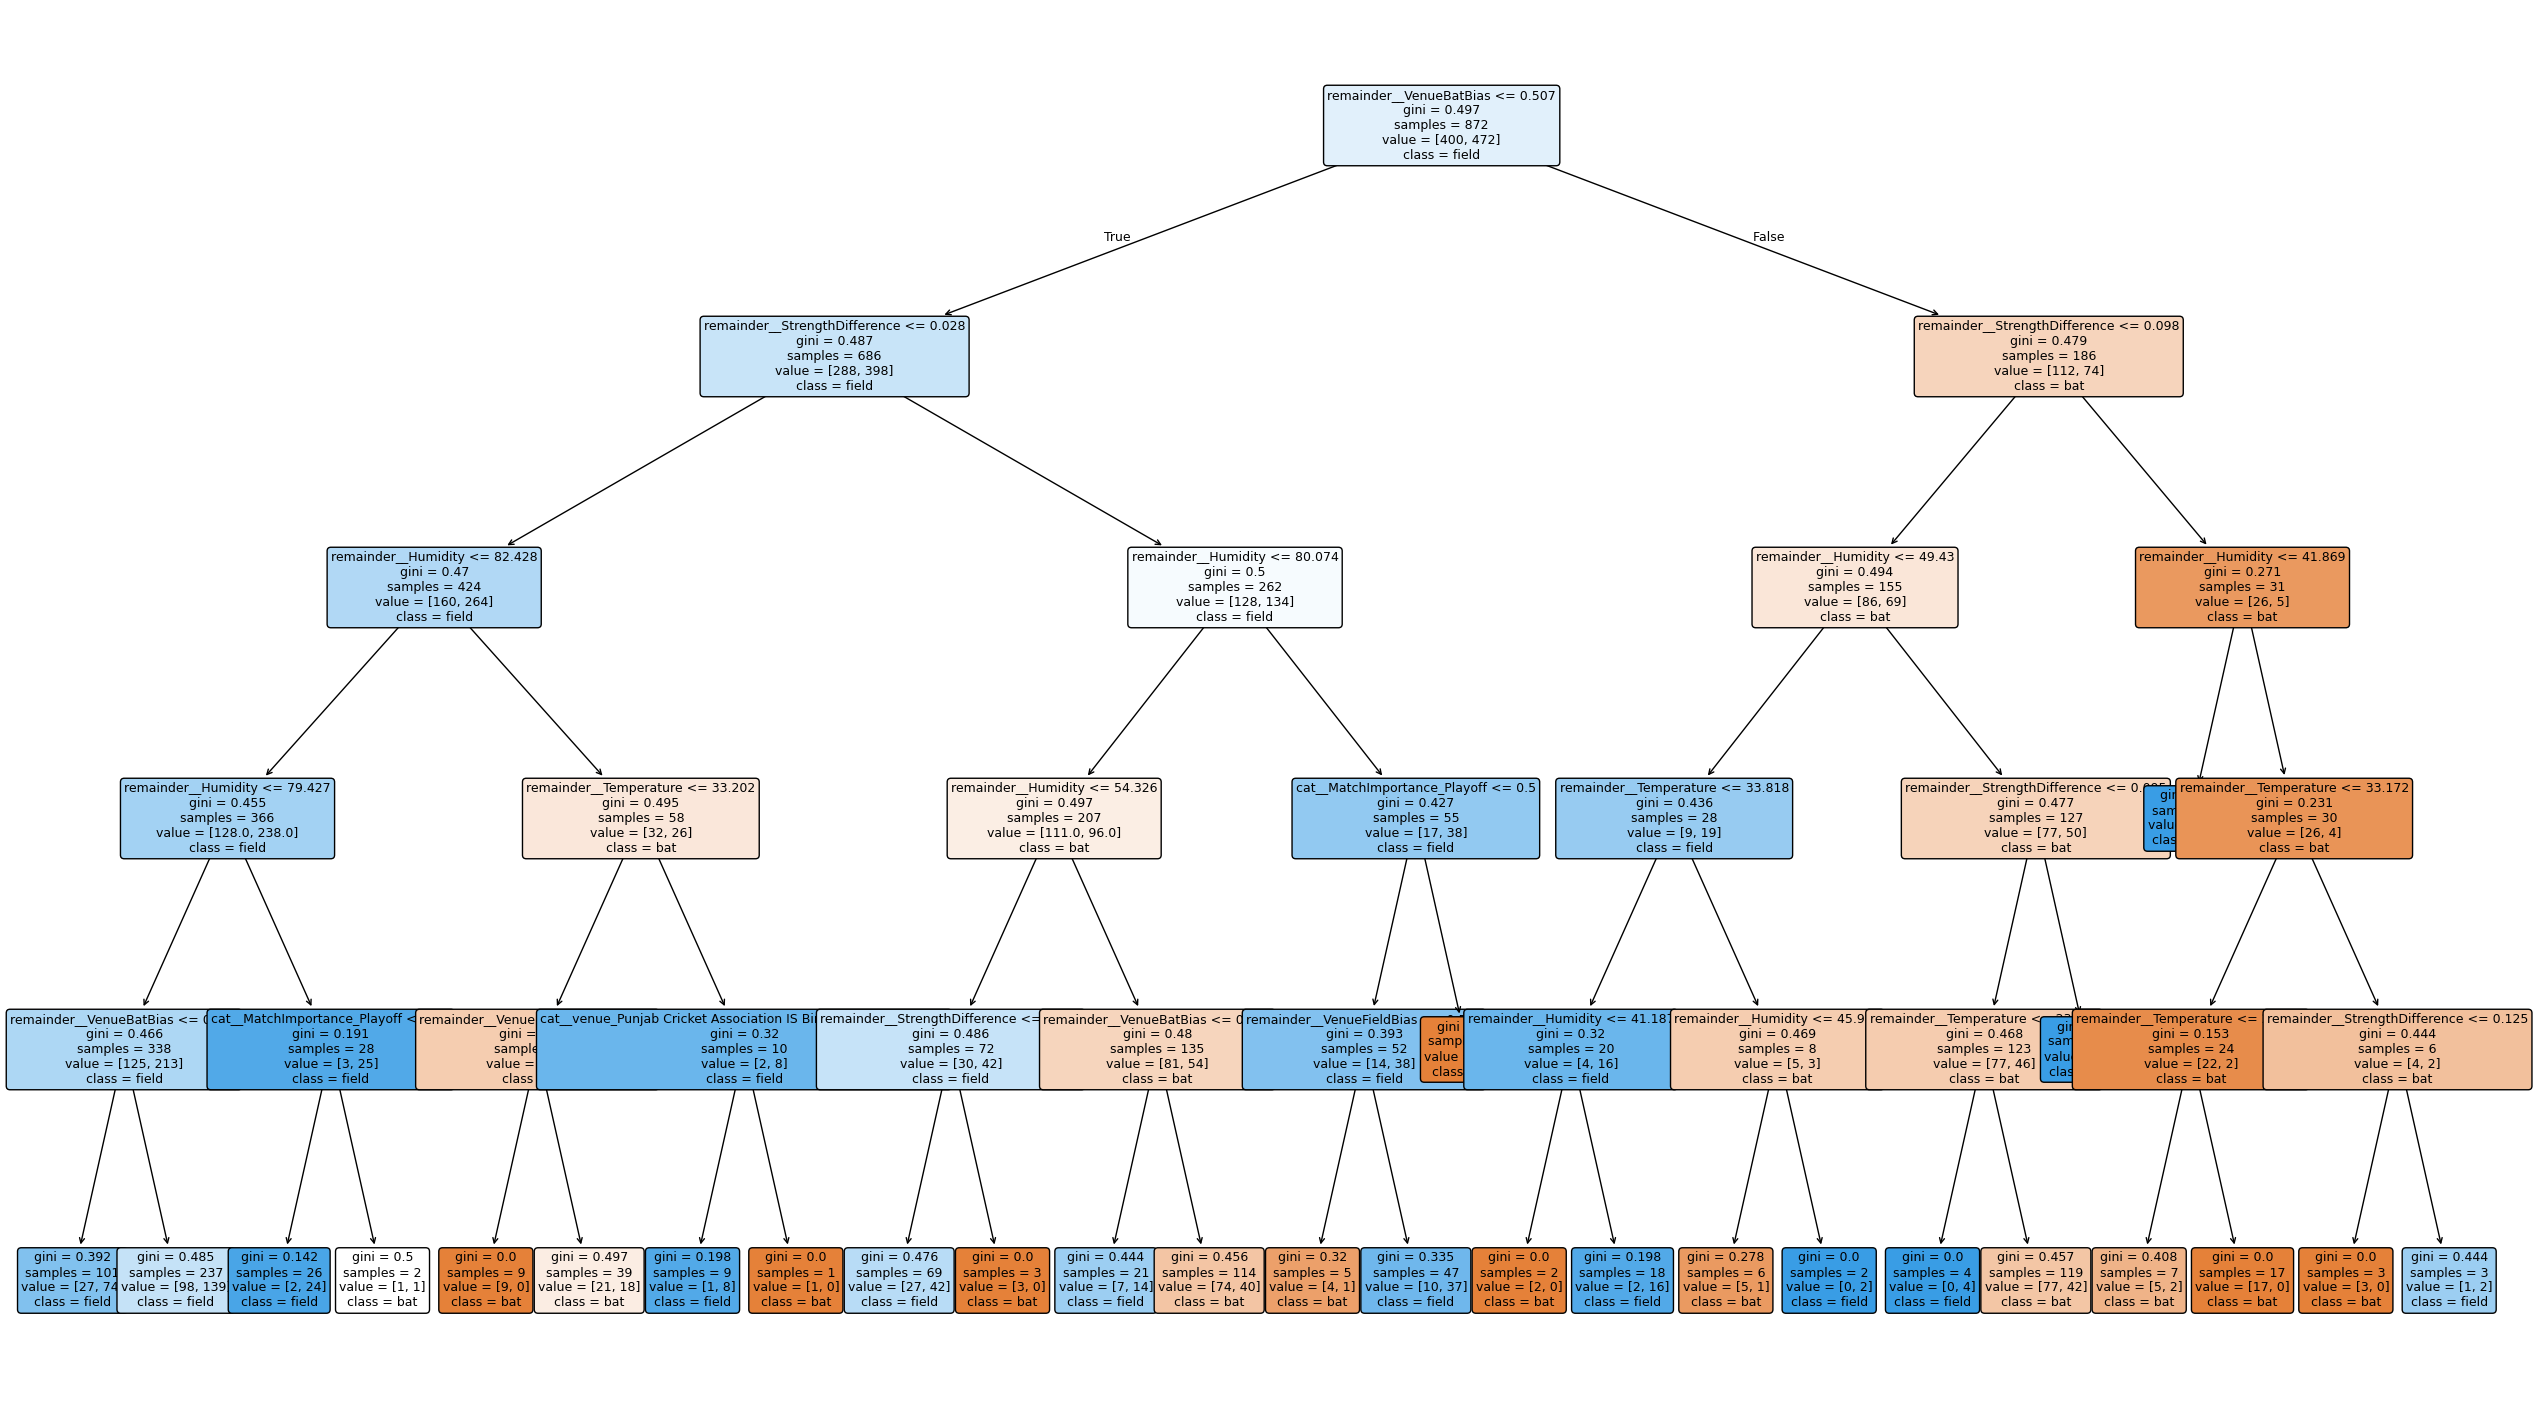

In [116]:
### 7. Visualization of tree
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(32,18))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

In [117]:
### 8. Visualization of tree

importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":tree.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

                                              Feature  Importance
43                                remainder__Humidity    0.328110
40                            remainder__VenueBatBias    0.210456
45                      remainder__StrengthDifference    0.189478
42                             remainder__Temperature    0.125356
41                          remainder__VenueFieldBias    0.080508
39                       cat__MatchImportance_Playoff    0.047721
26  cat__venue_Punjab Cricket Association IS Bindr...    0.018372
32                    cat__venue_Sheikh Zayed Stadium    0.000000
25                         cat__venue_OUTsurance Oval    0.000000
27      cat__venue_Rajiv Gandhi International Stadium    0.000000
28  cat__venue_Saurashtra Cricket Association Stadium    0.000000
29                  cat__venue_Sawai Mansingh Stadium    0.000000
30  cat__venue_Shaheed Veer Narayan Singh Internat...    0.000000
31                 cat__venue_Sharjah Cricket Stadium    0.000000
35        

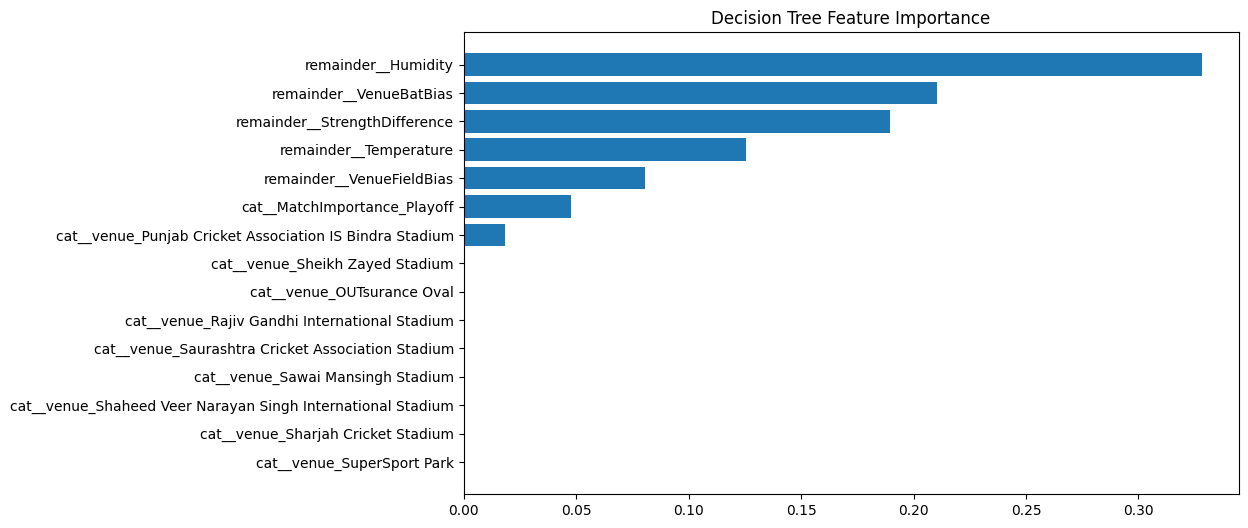

In [118]:
top = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top.Feature,
    top.Importance
)

plt.gca().invert_yaxis()

plt.title("Decision Tree Feature Importance")

plt.show()

In [119]:
### 9. Extract decision rules

rules = export_text(
    tree,
    feature_names=list(feature_names)
)

print(rules)

|--- remainder__VenueBatBias <= 0.51
|   |--- remainder__StrengthDifference <= 0.03
|   |   |--- remainder__Humidity <= 82.43
|   |   |   |--- remainder__Humidity <= 79.43
|   |   |   |   |--- remainder__VenueBatBias <= 0.42
|   |   |   |   |   |--- class: field
|   |   |   |   |--- remainder__VenueBatBias >  0.42
|   |   |   |   |   |--- class: field
|   |   |   |--- remainder__Humidity >  79.43
|   |   |   |   |--- cat__MatchImportance_Playoff <= 0.50
|   |   |   |   |   |--- class: field
|   |   |   |   |--- cat__MatchImportance_Playoff >  0.50
|   |   |   |   |   |--- class: bat
|   |   |--- remainder__Humidity >  82.43
|   |   |   |--- remainder__Temperature <= 33.20
|   |   |   |   |--- remainder__VenueFieldBias <= 0.53
|   |   |   |   |   |--- class: bat
|   |   |   |   |--- remainder__VenueFieldBias >  0.53
|   |   |   |   |   |--- class: bat
|   |   |   |--- remainder__Temperature >  33.20
|   |   |   |   |--- cat__venue_Punjab Cricket Association IS Bindra Stadium <= 0.50
|  

#### Using these rules above
| Match Situation                                                   | Recommendation  |
| ----------------------------------------------------------------- | --------------- |
| Venue has low batting bias (< 51%) and teams are evenly matched   | **Field first** |
| High humidity (> 79%) in a playoff match                          | **Bat first**   |
| Very humid (> 82%) and temperature ≤ 33°C                         | **Bat first**   |
| Teams are evenly matched with moderate humidity                   | **Field first** |
| Punjab Cricket Association IS Bindra Stadium under hot conditions | **Bat first**   |


##### Ques: Provide captains with data-driven toss decision recommendations

##### Ans: The Decision Tree recommends whether a captain should bat or field after winning the toss using historical venue trends, team strength differences, weather conditions, and match importance. The model first evaluates whether the venue historically favors batting or chasing, then adjusts its recommendation based on humidity, temperature, and the relative strengths of the competing teams. Because the model is interpretable, captains and coaching staff can understand the reasoning behind each recommendation rather than relying on a black-box prediction.

### Advanced Match Prediction - Ensemble Methods

#### We'll follow the following worflow: Feature Engineering → Random Forest → AdaBoost/XGBoost → Voting Ensemble → Model Comparison

In [120]:
### 1. Prepare Dataset
matches = df[df["winner"].notna()].copy()
matches["team1_win"] = (matches["winner"] == matches["team1"]).astype(int)

cat_cols = [
    "team1",
    "team2",
    "venue",
    "city",
    "toss_winner",
    "toss_decision",
    "match_type",
    "super_over"
]

num_cols = [
    "target_runs",
    "target_overs",
]

In [121]:
### 2. Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

X = matches[cat_cols + num_cols]
y = matches["team1_win"]

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#### Random Forest (Bagging)

In [123]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [124]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,20,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid_rf = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_rf.fit(
    X_train_processed,
    y_train
)

best_rf = grid_rf.best_estimator_

print(grid_rf.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [125]:
### Feature Importance

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(20))

                                          Feature  Importance
131                              num__target_runs    0.182829
23                      cat__team2_Mumbai Indians    0.018316
120                      cat__toss_decision_field    0.016899
25                        cat__team2_Punjab Kings    0.016218
119                        cat__toss_decision_bat    0.016180
112               cat__toss_winner_Mumbai Indians    0.016114
15                 cat__team2_Chennai Super Kings    0.015512
115             cat__toss_winner_Rajasthan Royals    0.014577
29                 cat__team2_Sunrisers Hyderabad    0.014247
28         cat__team2_Royal Challengers Bengaluru    0.014187
117  cat__toss_winner_Royal Challengers Bengaluru    0.013881
21               cat__team2_Kolkata Knight Riders    0.013872
26                    cat__team2_Rajasthan Royals    0.013865
110        cat__toss_winner_Kolkata Knight Riders    0.013670
132                             num__target_overs    0.013283
8       

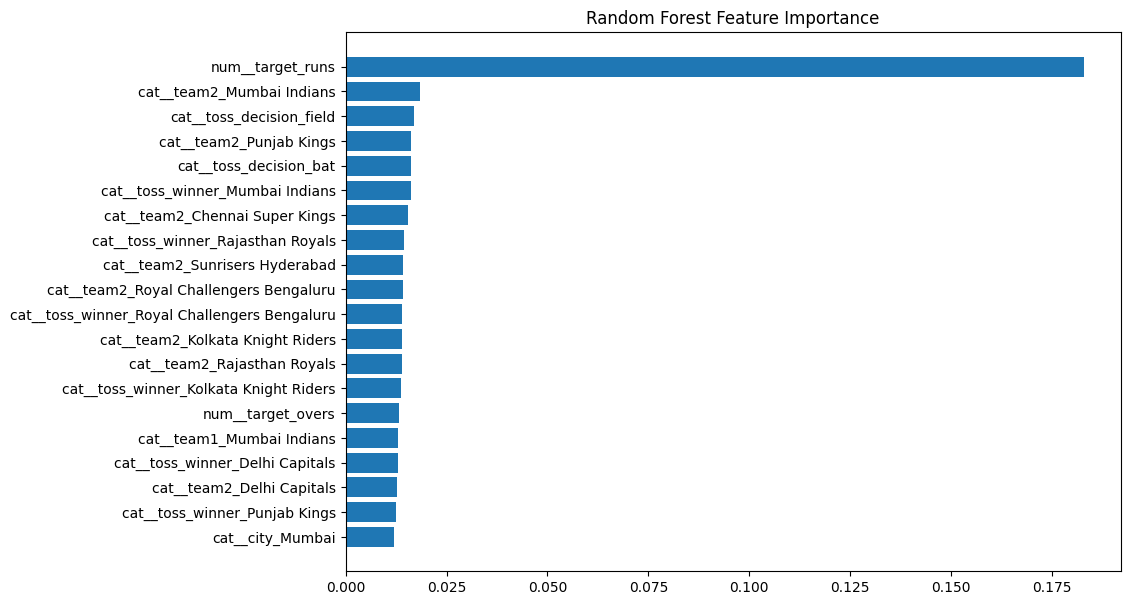

In [126]:
plt.figure(figsize=(10,7))

top = importance.head(20)

plt.barh(
    top.Feature,
    top.Importance
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.show()

#### AdaBoost (Boosting) and XGBoost

In [127]:
ada = AdaBoostClassifier(

    n_estimators=200,

    learning_rate=0.5,

    random_state=42

)

ada.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [128]:
xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"

)

xgb.fit(
    X_train_processed,
    y_train
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

#### Prediction Confidence

In [129]:
rf_prob = best_rf.predict_proba(
    X_test_processed
)[:,1]

ada_prob = ada.predict_proba(
    X_test_processed
)[:,1]

xgb_prob = xgb.predict_proba(
    X_test_processed
)[:,1]

#### Voting Ensemble

In [130]:
ensemble = VotingClassifier(
    estimators=[

        ("rf",best_rf),

        ("ada",ada),

        ("xgb",xgb)

    ],

    voting="soft"

)

ensemble.fit(
    X_train_processed,
    y_train
)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('ada', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


#### Performance Comparison

In [131]:
models = {

    "Random Forest":best_rf,

    "AdaBoost":ada,

    "XGBoost":xgb,

    "Ensemble":ensemble

}

results = []

for name,model in models.items():

    pred = model.predict(
        X_test_processed
    )

    results.append({

        "Model":name,

        "Accuracy":accuracy_score(y_test,pred),

        "Precision":precision_score(y_test,pred),

        "Recall":recall_score(y_test,pred),

        "F1":f1_score(y_test,pred)

    })

results = pd.DataFrame(results)

print(results)

           Model  Accuracy  Precision    Recall        F1
0  Random Forest  0.532110   0.542056  0.522523  0.532110
1       AdaBoost  0.518349   0.527778  0.513514  0.520548
2        XGBoost  0.513761   0.523364  0.504505  0.513761
3       Ensemble  0.545872   0.553571  0.558559  0.556054


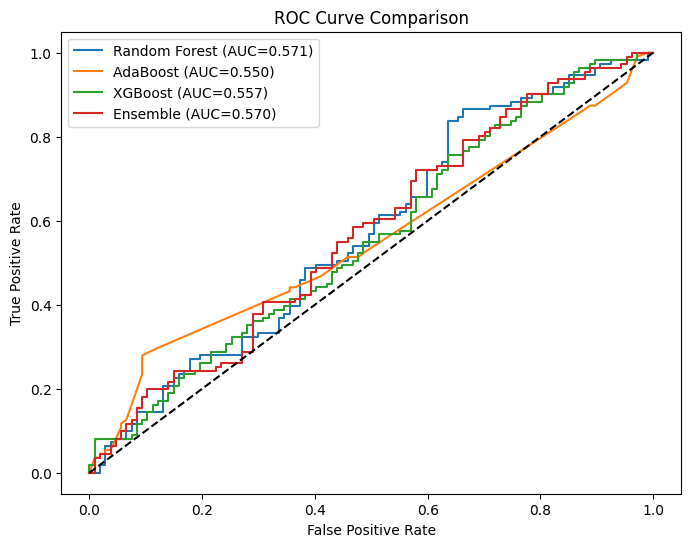

In [132]:
plt.figure(figsize=(8,6))

for name,model in models.items():

    prob = model.predict_proba(
        X_test_processed
    )[:,1]

    fpr,tpr,_ = roc_curve(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc(fpr,tpr):.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

1. Random Forest effectively captures complex interactions among teams, venues, and toss decisions while providing reliable feature importance scores.
2. AdaBoost/XGBoost sequentially focuses on difficult-to-predict matches, often yielding better predictive performance than a single decision tree.
3. The Voting Ensemble combines the strengths of both bagging and boosting, producing more robust and accurate match winner predictions with improved confidence estimates.
4. Feature importance analysis identifies the most influential factors, such as team identities, venue, toss winner, and target runs, enabling coaches and analysts to understand the drivers behind the predictions.